# Social Organization Founding Prediction Pipeline
**Dataset:** Base de respuestas 80 aniversario QS completa.csv  
**Target:** `founded_nonprofit` — whether an alumnus founded a nonprofit organization  
**Scope:** Data loading, preprocessing, and EDA. PCA and model selection handled separately.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
import os
os.makedirs('images', exist_ok=True)


## 1. Load Data

In [2]:
RAW_PATH  = 'Base de respuestas 80 aniversario QS completa.csv'
DICT_PATH = 'Data dictionary 80 anniv survey(1).csv'
SUPP_PATH = 'Data 80 aniversario study QS(1).csv'

# Row 0 is the question-text header, row 1 is the Qualtrics import label — skip both
raw = pd.read_csv(RAW_PATH, skiprows=[1, 2], low_memory=False)
print(f'Raw shape: {raw.shape}')
raw.head(2)

Raw shape: (25356, 223)


,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Acceso,External Data Reference,Género,Campus,Campus.1,Programa,programa nombre,Nivel,nivel_descripción,escuela,años de graduación,Decada,lustro,Location Latitude,Location Longitude,Distribution Channel,User Language,You are: Selected Choice,You are: I prefer describe myself like as: Text,How old are you?,nationality,...,"Please rate each of the following statements using the appropiare scale: In general, how would you rate your physical health?\n Where 1 = Very poor physical health, 10 = excellent physical health","Please rate each of the following statements using the appropiare scale: How would you rate your overall mental health?\n Where 1= very poor mental health, 10= excellent mental health","Please rate each of the following statements using the appropiare scale: I always act to promote good in all circumstances, even in difficult and challenging situations \n Where 1= Not true about me, 10 = Completely true about me","Please rate each of the following statements using the appropiare scale: I am always able to give up some happiness now for greater happiness later.\n Where 1= not true of me, 10 = totally true of me","Please rate each of the following statements using the appropiare scale: I am content with my friendships and relationships.\n Where 1 = strongly disagree, 10= Totally agree","Please rate each of the following statements using the appropiare scale: My relationships are as satisfying as I would want them to be \n Where 1= strongly disagree, 10= Totally agree","Please rate each of the following statements using the appropiare scale: How often do you worry about being able to meet normal monthly living expenses?\n Where 1= worry all of the time, 10= Do not ever worry","Please rate each of the following statements using the appropiare scale: How often do you worry about safety, food, or housing?\n Where 1= worry all the time, 10= Do not ever worry","Please rate each of the following statements using the appropiare scale: I understand my purpose in life \n Where 1 = strongly disagree, 10 = Strongly agree","According to your professional experience, how do you consider the preparedness received at Tecnologico de Monterrey compared to the preparedness of graduates from other universities?","Please rate on a scale of 0 to 10 the education you received at the Tecnologico de Monterrey, where 0 is Bad and 10 is Excellent The education I received at Tecnológico de Monterrey was:","On a scale of 0 to 10, where 0 is Strongly Disagree and 10 Strongly Agree, rate how much you agree with the following statements. I trust Tec de Monterrey","On a scale of 0 to 10, where 0 is Strongly Disagree and 10 Strongly Agree, rate how much you agree with the following statements. I feel committed to supporting Tec de Monterrey","On a scale of 0 to 10, where 0 is Strongly Disagree and 10 Strongly Agree, rate how much you agree with the following statements. If I were to study again in the future, Tecnológico de Monterrey would be my favorite","On a scale of 0 to 10, where 0 is Strongly Disagree and 10 Strongly Agree, rate how much you agree with the following statements. I would recommend others to study at Tec de Monterrey","On a scale of 0 to 10, where 0 is Strongly Disagree and 10 Strongly Agree, rate how much you agree with the following statements. Tec de Monterrey is always in my heart","Durante su carrera en el Tec de Monterrey, conoció a alguien que: Q46#1 a. Is or was your sentimental partner","Durante su carrera en el Tec de Monterrey, conoció a alguien que: Q46#1 b. Is or was your partner in companies or organizations","Durante su carrera en el Tec de Monterrey, conoció a alguien que: Q46#1 c. Is or was one of your main friends","Durante su carrera en el Tec de Monterrey, conoció a alguien que: Q46#1 d. Made it easy for you to find good jobs","Indicate how much you agree with each statement, on a scale of 1 to 10, whe

In [3]:
data_dict = pd.read_csv(DICT_PATH)
supp      = pd.read_csv(SUPP_PATH, low_memory=False)
print('Data dictionary shape:', data_dict.shape)
print('Supplementary shape:  ', supp.shape)
data_dict.head(10)

Data dictionary shape: (72, 4)
Supplementary shape:   (25358, 72)


,Variable,Data Type,Values,Unnamed: 3
0,External Data Reference,Identifier,All different,NaN
1,Gender,Binary,"F: Woman, H: Man",NaN
2,Campus,String,Many,SD: Not identified
3,programa nombre,String,Many,NaN
4,nivel_descripción,String,Many,NaN
5,escuela,String,Many,NaN
6,años de graduación,Integer,Many,NaN
7,Decada,String,Many,NaN
8,lustro,String,Many,NaN
9,AGE,Integer,Many,NaN


## 2. Column Renaming
The survey columns have very long Qualtrics labels. We map them to short, readable names.

In [4]:
rename_map = {
    # --- identifiers / metadata ---
    'External Data Reference':                             'respondent_id',
    'Género':                                              'gender',
    'Campus':                                              'campus',
    'programa nombre':                                     'program_name',
    'nivel_descripción':                                   'academic_level',
    'escuela':                                             'school',
    'años de graduación':                                  'grad_year',
    'Decada':                                              'decade',
    'lustro':                                              'lustrum',

    # --- demographics ---
    'How old are you?':                                    'age',
    'nationality':                                         'nationality',
    'living country':                                      'living_country',
    'In which state do you live?':                         'living_state',
    'living country  before studies':                      'country_before_studies',
    'living state  before studies':                        'state_before_studies',
    'You are:  Selected Choice':                           'gender_identity',

    # --- family background ---
    'Which is the education level of your parents?  Father': 'parent_edu_father',
    'Which is the education level of your parents?  Mother': 'parent_edu_mother',
    'Which of the following best describes the occupation of your father and mother when you began your studies at Tecnologico de Monterrey?  Father': 'parent_occ_father',
    'Which of the following best describes the occupation of your father and mother when you began your studies at Tecnologico de Monterrey?  Mother': 'parent_occ_mother',

    # --- academic background ---
    "During your studies at Tecnologico de Monterrey, did you receive the support of any scholarship (scholarship is understood as economic resources, which you did not have to reimburse at the end of your program)": 'scholarship',
    'What percentage of support did you receive from the scholarship?':                'scholarship_pct',
    'Have you completed postgraduate studies?':                                        'postgrad',
    'Por favor, háganos saber lo que estudió  CONTESTE TODAS LAS COLUMNAS HACIA LA DERECHA     Study level  Program 1': 'postgrad_level_1',

    # --- career ---
    'Please select the option that best describes your current situation  Selected Choice': 'employment_status',
    'How many hours do you usually work per week?':                                    'weekly_hours',
    'Por favor conteste las siguientes preguntas de los puestos de trabajo que ha tenido.  Se entiende...  Position  2. Current job position (If you are not currently working, describe the last job position)': 'current_position',
    'Por favor conteste las siguientes preguntas de los puestos de trabajo que ha tenido.  Se entiende...  Sector  2. Current job position (If you are not currently working, describe the last job position)': 'current_sector',
    'Por favor conteste las siguientes preguntas de los puestos de trabajo que ha tenido.  Se entiende...  Organization size  2. Current job position (If you are not currently working, describe the last job position)': 'org_size_current',
    'salary  Gross monthly income (before taxes, numbers only)  2. Current job position (If you are not currently working, describe the las...  2. Current job position (If you are not currently working, describe the last job position)  (pesos per month)': 'salary_current',
    'salary  Gross monthly income (before taxes, numbers only)  1. Your first formal job after graduating from professional level  (pesos per month)': 'salary_first_job',
    'After your graduation, have you worked abroad during your professional career?':  'worked_abroad',
    'How many years have you worked abroad ?':                                         'years_abroad',
    'In your current job position, how many people report to you?':                   'direct_reports',
    "In your current job, how often do you apply the knowledge, skills and/or technology tools specific to your LAST academic program studied at Tecnológico de Monterrey? (On a scale from 1 to 10 where 1=Never and 10=Always) ": 'knowledge_application',

    # --- leadership ---
    "En su trayectoria profesional, ¿ha ocupado alguno de los siguientes puestos?  Q18#1  VP/ Deputy Director":           'held_vp',
    "En su trayectoria profesional, ¿ha ocupado alguno de los siguientes puestos?  Q18#1  Chief Executive Officer (CEO)": 'held_ceo',
    "En su trayectoria profesional, ¿ha ocupado alguno de los siguientes puestos?  Q18#1  Director in some area of a company (Finance, Operations, Sales, Human Resources, IT, Logistics and others)": 'held_director',
    "En su trayectoria profesional, ¿ha ocupado alguno de los siguientes puestos?  Q18#1  Head of  a secretariat, institute, agency or social and/or public organization, NGO": 'held_ngo_head',
    "En su trayectoria profesional, ¿ha ocupado alguno de los siguientes puestos?  Q18#1  Elected office position (Congressman, Senator, Mayor, Governor, etc. )": 'held_elected',

    # --- entrepreneurship / advisory ---
    "Since graduating from Tecnológico de Monterrey, have you founded a company, either as part of the group of partners or as owner? By partner we mean those who contributed money and/or work to start the company": 'founded_company',
    'Have you participated as an Advisor in any Advisory Boards of a company?':        'advisory_board',

    # --- TARGET ---
    "Since graduating from Tecnológico de Monterrey, have you founded a nonprofit organization, as part of the founding group or main founder?": 'founded_nonprofit',
    'How many organizations have you founded?':                                        'num_orgs_founded',
    'How many are still in operation (actives)?':                                      'num_orgs_active',

    # --- social engagement ---
    'Do you regularly donate money to social organizations?':                          'donates_money',
    "How much money per year do you donate to social organizations? If you donate in another currency, please select an approximate amount in Mexican pesos..": 'donation_amount',
    "During the last year, have you done any volunteer work (unpaid) for social organizations?": 'volunteers',
    'Would you please share an estimate amount of how many hours per MONTH you donate to social organizations?  hours per month': 'volunteer_hours_month',

    # --- job satisfaction ---
    "Taking into consideration all relevant aspects of your work experience provided by your current job, on a scale of 1 to 10, where 1 is Not satisfied and 10 is Very satisfied, how satisfied are you with your current job?": 'job_satisfaction',
    "Working brings different benefits in addition to a salary, such as personal development, learning, personal relationships, personal fulfillment, among others. Based on the monthly salary that you have reported in this survey, how much do you value these intangible benefits that you may or may not receive from your current job:": 'intangible_benefits_value',

    # --- Tec competencies at graduation ---
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  1. Selfknowledge and management: Know yourself and be a good planner and manager.': 'grad_comp_selfknowledge',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  2. Innovative entrepreneurship: Not only start companies but be an agent of change, innovative and with social impact.': 'grad_comp_entrepreneurship',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  3. Social intelligence: Knowing how to relate and interact with other people and cultures, as well as knowing how to negotiate.': 'grad_comp_social_intel',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  4. Ethics and citizenship: Develop a sense of citizenship, honesty and act with integrity and ethics.': 'grad_comp_ethics',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  5. Reasoning for complexity: Recognize that the world is complex and know how to use methodologies and strategies such as design thinking, critical thinking and learning to learn.': 'grad_comp_complexity',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  6. Communication: Use the native language well orally and in writing. In addition to being efficient when presenting an idea and mastering other languages.': 'grad_comp_communication',
    'Rate each of these competencies according to your perception of your level of personal achievement, upon graduation from the last degree obtained at the Tecnológico de Monterrey).  7. Digital transformation: Use technology to enhance and make processes more efficient.': 'grad_comp_digital',

    # --- current competencies ---
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  1. Selfknowledge and management: Know yourself and be a good planner and manager.': 'now_comp_selfknowledge',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  2. Innovative entrepreneurship: Not only start companies but be an agent of change, innovative and with social impact.': 'now_comp_entrepreneurship',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  3. Social intelligence: Knowing how to relate and interact with other people and cultures, as well as knowing how to negotiate.': 'now_comp_social_intel',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  4. Ethics and citizenship: Develop a sense of citizenship, honesty and act with integrity and ethics.': 'now_comp_ethics',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  5. Reasoning for complexity: Recognize that the world is complex and know how to use methodologies and strategies such as design thinking, critical thinking and learning to learn.': 'now_comp_complexity',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  6. Communication: Use the native language well orally and in writing. In addition to being efficient when presenting an idea and mastering other languages.': 'now_comp_communication',
    'UP TODAY please rate each of these competencies according to your perceived level of personal achievement. Where 1= Lowest achievemnt anf 10=Highest achievement level.  7. Digital transformation: Use technology to enhance and make processes more efficient.': 'now_comp_digital',

    # --- wellbeing ---
    'Please rate each of the following statements using the appropiare scale:  In general, how happy or unhappy do you usually feel?\n extremely unhappy:Where 1=Extremely unhappy, 10=Extremely happy': 'wb_happiness',
    'Please rate each of the following statements using the appropiare scale:  Overall, how satisfied are you with life as a whole these days??\n Where 1 = Not satisfied at all, 10 = Completely Satisfied': 'wb_life_satisfaction',
    'Please rate each of the following statements using the appropiare scale:  IOverall, to what extent do you feel the things you do in your life are worthwhile? \n Where 1 is = Not at All Worthwhile, and 10 = Completely Worthwhile': 'wb_worthwhile',
    'Please rate each of the following statements using the appropiare scale:  In general, how would you rate your physical health?\n Where 1 = Very poor physical health, 10 = excellent physical health': 'wb_physical_health',
    'Please rate each of the following statements using the appropiare scale:  How would you rate your overall mental health?\n Where 1= very poor mental health, 10= excellent mental health': 'wb_mental_health',
    'Please rate each of the following statements using the appropiare scale:  I always act to promote good in all circumstances, even in difficult and challenging  situations \n Where 1= Not true about me, 10 = Completely true about me': 'wb_promote_good',
    'Please rate each of the following statements using the appropiare scale:  I am always able to give up some happiness now for greater happiness later.\n Where 1= not true of me, 10 = totally true of me': 'wb_delayed_gratification',
    'Please rate each of the following statements using the appropiare scale:  I am content with my friendships and relationships.\n Where 1 = strongly disagree, 10= Totally agree': 'wb_friendships',
    'Please rate each of the following statements using the appropiare scale:  My relationships are as satisfying as I would want them to be \n Where 1= strongly disagree, 10= Totally agree': 'wb_relationships',
    'Please rate each of the following statements using the appropiare scale:  How often do you worry about being able to meet normal monthly living expenses?\n Where 1= worry all of the time, 10= Do not ever worry': 'wb_financial_worry',
    'Please rate each of the following statements using the appropiare scale:  How often do you worry about safety, food, or housing?\n Where 1= worry all the time, 10= Do not ever worry': 'wb_safety_worry',
    'Please rate each of the following statements using the appropiare scale:  I understand my purpose in life \n Where 1 = strongly disagree, 10 = Strongly agree': 'wb_purpose',
}

df = raw.rename(columns=rename_map)
print(f'Renamed dataframe shape: {df.shape}')
print('Columns kept after rename:')
print([c for c in df.columns if c in rename_map.values()])

Renamed dataframe shape: (25356, 223)
Columns kept after rename:
['respondent_id', 'gender', 'campus', 'program_name', 'academic_level', 'school', 'grad_year', 'decade', 'lustrum', 'gender_identity', 'age', 'nationality', 'living_country', 'living_state', 'country_before_studies', 'state_before_studies', 'parent_edu_father', 'parent_edu_mother', 'parent_occ_father', 'parent_occ_mother', 'scholarship', 'scholarship_pct', 'postgrad', 'employment_status', 'weekly_hours', 'salary_first_job', 'salary_current', 'job_satisfaction', 'intangible_benefits_value', 'worked_abroad', 'years_abroad', 'held_vp', 'held_ceo', 'held_director', 'held_elected', 'direct_reports', 'knowledge_application', 'grad_comp_selfknowledge', 'grad_comp_entrepreneurship', 'grad_comp_social_intel', 'grad_comp_ethics', 'grad_comp_complexity', 'grad_comp_communication', 'grad_comp_digital', 'now_comp_selfknowledge', 'now_comp_entrepreneurship', 'now_comp_social_intel', 'now_comp_ethics', 'now_comp_complexity', 'now_comp_c

## 3. Select Relevant Columns

In [5]:
FEATURE_COLS = [
    # identity / demographics
    'gender', 'age', 'nationality', 'living_country',
    'country_before_studies',
    # academic
    'program_name', 'academic_level', 'school', 'grad_year', 'decade', 'lustrum',
    'scholarship', 'scholarship_pct', 'postgrad', 'postgrad_level_1',
    # family background
    'parent_edu_father', 'parent_edu_mother',
    'parent_occ_father', 'parent_occ_mother',
    # career
    'employment_status', 'weekly_hours', 'current_sector', 'org_size_current',
    'salary_current', 'salary_first_job',
    'worked_abroad', 'years_abroad', 'direct_reports', 'knowledge_application',
    # leadership
    'held_vp', 'held_ceo', 'held_director', 'held_ngo_head', 'held_elected',
    # entrepreneurship
    'founded_company', 'advisory_board',
    # social engagement
    'donates_money', 'donation_amount', 'volunteers', 'volunteer_hours_month',
    # job satisfaction
    'job_satisfaction', 'intangible_benefits_value',
    # Tec competencies (at graduation)
    'grad_comp_selfknowledge', 'grad_comp_entrepreneurship', 'grad_comp_social_intel',
    'grad_comp_ethics', 'grad_comp_complexity', 'grad_comp_communication', 'grad_comp_digital',
    # current competencies
    'now_comp_selfknowledge', 'now_comp_entrepreneurship', 'now_comp_social_intel',
    'now_comp_ethics', 'now_comp_complexity', 'now_comp_communication', 'now_comp_digital',
    # wellbeing
    'wb_happiness', 'wb_life_satisfaction', 'wb_worthwhile', 'wb_physical_health',
    'wb_mental_health', 'wb_promote_good', 'wb_delayed_gratification',
    'wb_friendships', 'wb_relationships', 'wb_financial_worry', 'wb_safety_worry', 'wb_purpose',
]

TARGET_COL = 'founded_nonprofit'

# Keep only columns that actually exist in the dataframe
available_features = [c for c in FEATURE_COLS if c in df.columns]
missing_features   = [c for c in FEATURE_COLS if c not in df.columns]

df_model = df[available_features + ([TARGET_COL] if TARGET_COL in df.columns else [])].copy()
print(f'Model dataframe shape: {df_model.shape}')
if missing_features:
    print(f'\nFeatures not found in data (check rename_map): {missing_features}')

Model dataframe shape: (25356, 65)

Features not found in data (check rename_map): ['postgrad_level_1', 'current_sector', 'org_size_current', 'held_ngo_head']


## 4. Target Variable — Encoding

In [6]:
print('Raw target values:')
print(df_model[TARGET_COL].value_counts(dropna=False))

yes_no_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
df_model[TARGET_COL] = df_model[TARGET_COL].map(yes_no_map)

print('\nEncoded target values:')
print(df_model[TARGET_COL].value_counts(dropna=False))
print(f'\nClass balance: {df_model[TARGET_COL].mean():.2%} founded a nonprofit')

Raw target values:
founded_nonprofit
No     23593
Yes     1763
Name: count, dtype: int64

Encoded target values:
founded_nonprofit
0    23593
1     1763
Name: count, dtype: int64

Class balance: 6.95% founded a nonprofit


## 5. Missing-Value Analysis

In [7]:
missing = (
    df_model.isnull().sum()
    .rename('missing_n')
    .to_frame()
    .assign(missing_pct=lambda x: x['missing_n'] / len(df_model) * 100)
    .sort_values('missing_pct', ascending=False)
)
print(missing[missing['missing_n'] > 0].to_string())

                           missing_n  missing_pct
years_abroad                   17304    68.244203
volunteer_hours_month          16769    66.134248
donation_amount                15621    61.606720
scholarship_pct                10569    41.682442
held_elected                    2588    10.206657
held_vp                         1996     7.871904
held_ceo                        1758     6.933270
weekly_hours                    1707     6.732134
salary_current                  1297     5.115160
salary_first_job                1007     3.971447
held_director                    801     3.159016
parent_occ_father                254     1.001735
now_comp_ethics                  147     0.579744
now_comp_digital                 137     0.540306
now_comp_complexity              122     0.481148
now_comp_social_intel            116     0.457485
now_comp_communication           103     0.406215
now_comp_entrepreneurship         89     0.351002
now_comp_selfknowledge            85     0.335226


In [8]:
HIGH_MISSING_THRESH = 60  # % threshold to drop a column
cols_to_drop = missing[missing['missing_pct'] > HIGH_MISSING_THRESH].index.tolist()
print(f'Dropping {len(cols_to_drop)} columns with >{HIGH_MISSING_THRESH}% missing:\n{cols_to_drop}')
df_model.drop(columns=cols_to_drop, inplace=True)

Dropping 3 columns with >60% missing:
['years_abroad', 'volunteer_hours_month', 'donation_amount']


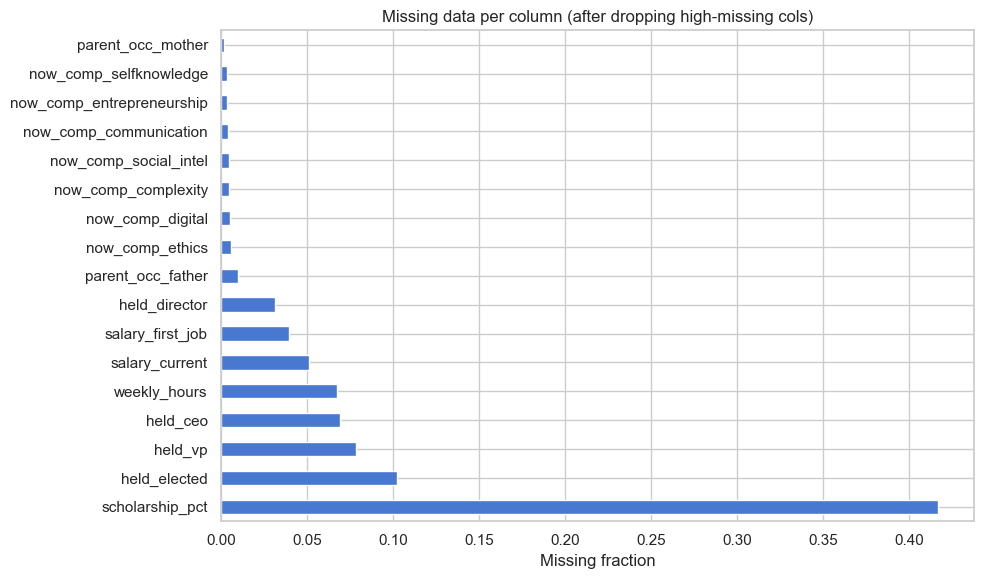

In [9]:
# Visualise remaining missing data
remaining_missing = df_model.isnull().mean().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(remaining_missing) * 0.35)))
    remaining_missing.plot(kind='barh', ax=ax)
    ax.set_xlabel('Missing fraction')
    ax.set_title('Missing data per column (after dropping high-missing cols)')
    plt.tight_layout()
    plt.show()
else:
    print('No missing data remaining.')

## 6. Type Inference & Categorical Encoding

In [10]:
BINARY_COLS = [
    'scholarship', 'postgrad', 'worked_abroad', 'held_vp', 'held_ceo',
    'held_director', 'held_ngo_head', 'held_elected',
    'founded_company', 'advisory_board', 'donates_money', 'volunteers',
]

for col in BINARY_COLS:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(yes_no_map)

# Ordinal parent education (rough ordering)
edu_order = [
    'No formal education',
    'Primary school',
    'Secondary school / middle school',
    'High school / preparatory',
    'Technical / vocational',
    'Bachelor',
    "Bachelor's degree",
    'Postgraduate',
    "Master's degree",
    'Doctorate / PhD',
]
edu_map = {v: i for i, v in enumerate(edu_order)}

for col in ['parent_edu_father', 'parent_edu_mother']:
    if col in df_model.columns:
        df_model[col + '_ord'] = df_model[col].map(edu_map)

# Numeric columns that may have come in as strings
NUMERIC_COLS = [
    'age', 'grad_year', 'weekly_hours', 'salary_current', 'salary_first_job',
    'years_abroad', 'direct_reports', 'knowledge_application',
    'volunteer_hours_month', 'num_orgs_founded', 'num_orgs_active',
    'job_satisfaction', 'intangible_benefits_value',
    'grad_comp_selfknowledge', 'grad_comp_entrepreneurship', 'grad_comp_social_intel',
    'grad_comp_ethics', 'grad_comp_complexity', 'grad_comp_communication', 'grad_comp_digital',
    'now_comp_selfknowledge', 'now_comp_entrepreneurship', 'now_comp_social_intel',
    'now_comp_ethics', 'now_comp_complexity', 'now_comp_communication', 'now_comp_digital',
    'wb_happiness', 'wb_life_satisfaction', 'wb_worthwhile', 'wb_physical_health',
    'wb_mental_health', 'wb_promote_good', 'wb_delayed_gratification',
    'wb_friendships', 'wb_relationships', 'wb_financial_worry', 'wb_safety_worry', 'wb_purpose',
]

for col in NUMERIC_COLS:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

print('dtypes after encoding:')
print(df_model.dtypes.value_counts())

dtypes after encoding:
int64      28
float64    22
object     14
Name: count, dtype: int64


## 7. Imputation

In [11]:
from sklearn.impute import SimpleImputer

# Drop all-NaN columns before imputing — SimpleImputer silently removes them,
# which causes a column-count mismatch when assigning back.
all_nan_cols = [c for c in df_model.columns if df_model[c].isna().all()]
if all_nan_cols:
    print(f'Dropping all-NaN columns: {all_nan_cols}')
    df_model.drop(columns=all_nan_cols, inplace=True)

# Recompute column lists after any drops
num_cols = df_model.select_dtypes(include='number').columns.drop(TARGET_COL, errors='ignore').tolist()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

# Median imputation for numerics
num_imputer = SimpleImputer(strategy='median')
df_model[num_cols] = num_imputer.fit_transform(df_model[num_cols])

# Mode imputation for categoricals
cat_imputer = SimpleImputer(strategy='most_frequent')
df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])

# Drop rows where target is still NaN
df_model = df_model.dropna(subset=[TARGET_COL])
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

print(f'Shape after imputation: {df_model.shape}')
print(f'Remaining nulls: {df_model.isnull().sum().sum()}')

Dropping all-NaN columns: ['intangible_benefits_value']
Shape after imputation: (25356, 63)
Remaining nulls: 0


## 8. Feature Engineering

In [12]:
# Years since graduation (proxy for professional experience)
SURVEY_YEAR = 2024
if 'grad_year' in df_model.columns:
    df_model['years_since_grad'] = SURVEY_YEAR - df_model['grad_year']

# Aggregate competency scores
grad_comp_cols = [c for c in df_model.columns if c.startswith('grad_comp_')]
now_comp_cols  = [c for c in df_model.columns if c.startswith('now_comp_')]
wb_cols        = [c for c in df_model.columns if c.startswith('wb_')]

if grad_comp_cols:
    df_model['grad_comp_avg'] = df_model[grad_comp_cols].mean(axis=1)
if now_comp_cols:
    df_model['now_comp_avg']  = df_model[now_comp_cols].mean(axis=1)
if wb_cols:
    df_model['wellbeing_avg'] = df_model[wb_cols].mean(axis=1)

# Competency growth (current - at graduation)
comp_domains = ['selfknowledge', 'entrepreneurship', 'social_intel',
                'ethics', 'complexity', 'communication', 'digital']
for d in comp_domains:
    g, n = f'grad_comp_{d}', f'now_comp_{d}'
    if g in df_model.columns and n in df_model.columns:
        df_model[f'comp_growth_{d}'] = df_model[n] - df_model[g]

# Leadership breadth (number of senior roles held)
leadership_cols = [c for c in ['held_vp', 'held_ceo', 'held_director', 'held_ngo_head', 'held_elected']
                   if c in df_model.columns]
if leadership_cols:
    df_model['leadership_breadth'] = df_model[leadership_cols].sum(axis=1)

# Salary ratio (growth proxy)
if 'salary_current' in df_model.columns and 'salary_first_job' in df_model.columns:
    df_model['salary_ratio'] = np.where(
        df_model['salary_first_job'] > 0,
        df_model['salary_current'] / df_model['salary_first_job'],
        np.nan
    )

print('Engineered features added. New shape:', df_model.shape)

Engineered features added. New shape: (25356, 76)


## 9. Exploratory Data Analysis

### 9.1 Target Distribution

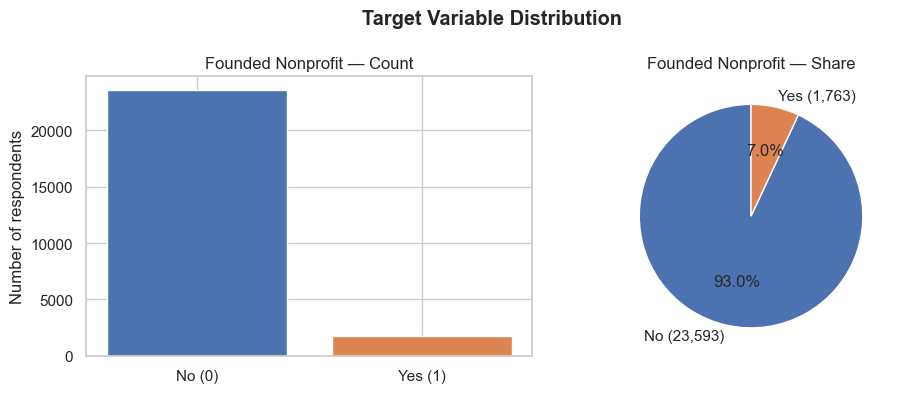

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df_model[TARGET_COL].value_counts()
axes[0].bar(['No (0)', 'Yes (1)'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Founded Nonprofit — Count')
axes[0].set_ylabel('Number of respondents')

axes[1].pie(
    counts.values,
    labels=[f'No ({counts[0]:,})', f'Yes ({counts[1]:,})'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90
)
axes[1].set_title('Founded Nonprofit — Share')
plt.suptitle('Target Variable Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Demographics

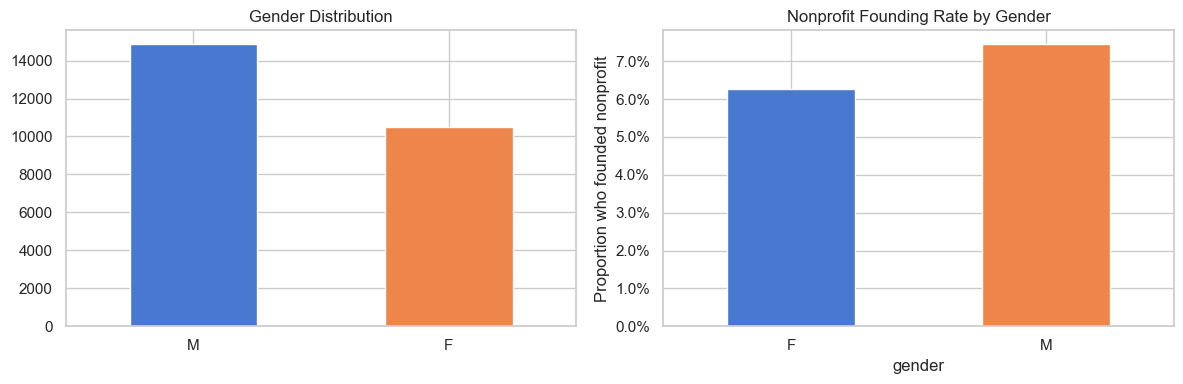

In [14]:
# Gender breakdown
if 'gender' in df_model.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    gender_counts = df_model['gender'].value_counts()
    gender_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(gender_counts)))
    axes[0].set_title('Gender Distribution')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)

    gender_target = df_model.groupby('gender')[TARGET_COL].mean()
    gender_target.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', len(gender_target)))
    axes[1].set_title('Nonprofit Founding Rate by Gender')
    axes[1].set_ylabel('Proportion who founded nonprofit')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig('images/gender_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

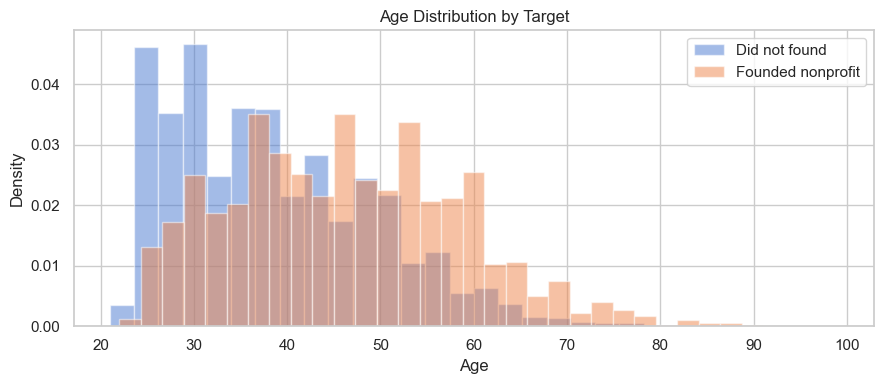

Age stats by target:
                     count  mean   std   min   25%   50%   75%   max
founded_nonprofit                                                   
0                  23593.0  38.3  10.8  21.0  29.0  37.0  46.0  99.0
1                   1763.0  46.1  12.3  22.0  37.0  45.0  55.0  91.0


In [15]:
# Age distribution by target
if 'age' in df_model.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    for val, label in [(0, 'Did not found'), (1, 'Founded nonprofit')]:
        subset = df_model[df_model[TARGET_COL] == val]['age'].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=label, density=True)
    ax.set_xlabel('Age')
    ax.set_ylabel('Density')
    ax.set_title('Age Distribution by Target')
    ax.legend()
    plt.tight_layout()
    plt.savefig('images/age_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Age stats by target:')
    print(df_model.groupby(TARGET_COL)['age'].describe().round(1))

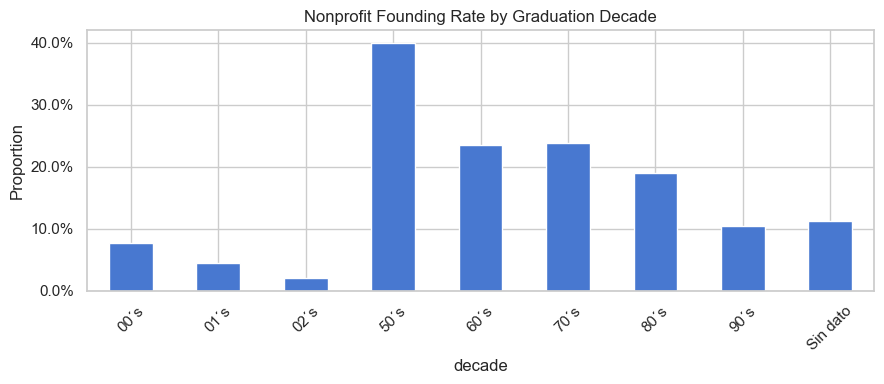

In [16]:
# Graduation decade vs founding rate
if 'decade' in df_model.columns:
    decade_rate = df_model.groupby('decade')[TARGET_COL].mean().sort_index()
    fig, ax = plt.subplots(figsize=(9, 4))
    decade_rate.plot(kind='bar', ax=ax)
    ax.set_title('Nonprofit Founding Rate by Graduation Decade')
    ax.set_ylabel('Proportion')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('images/graduation_decade_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.3 Academic Background

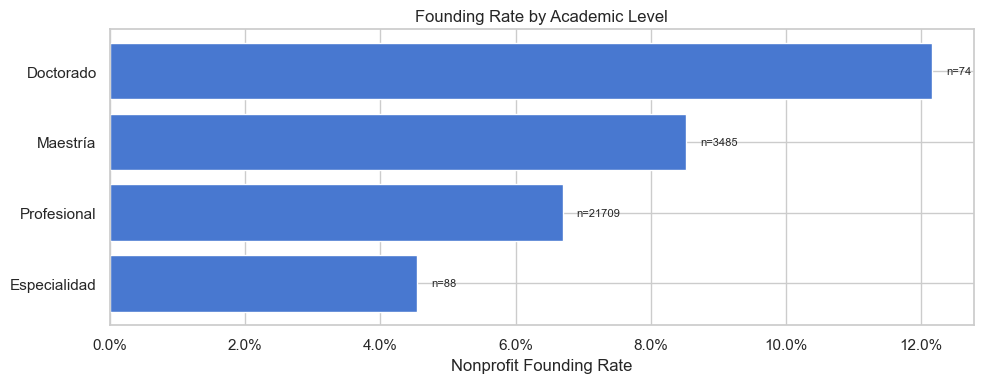

In [17]:
# Academic level vs founding rate
if 'academic_level' in df_model.columns:
    level_rate = df_model.groupby('academic_level')[TARGET_COL].agg(['mean', 'count'])
    level_rate.columns = ['founding_rate', 'n']
    level_rate = level_rate.sort_values('founding_rate', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(level_rate) * 0.5)))
    bars = ax.barh(level_rate.index, level_rate['founding_rate'])
    ax.set_xlabel('Nonprofit Founding Rate')
    ax.set_title('Founding Rate by Academic Level')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for bar, (_, row) in zip(bars, level_rate.iterrows()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'n={int(row["n"])}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('images/academic_level_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

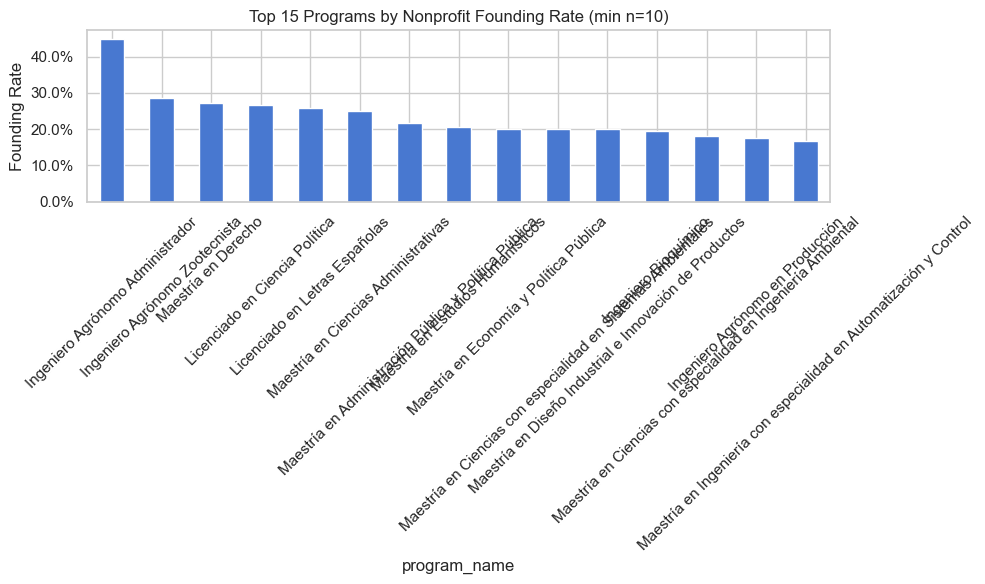

In [18]:
# Top 15 programs by founding rate (min 10 respondents)
if 'program_name' in df_model.columns:
    prog_stats = (
        df_model.groupby('program_name')[TARGET_COL]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'founding_rate', 'count': 'n'})
        .query('n >= 10')
        .sort_values('founding_rate', ascending=False)
        .head(15)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    prog_stats['founding_rate'].plot(kind='bar', ax=ax)
    ax.set_title('Top 15 Programs by Nonprofit Founding Rate (min n=10)')
    ax.set_ylabel('Founding Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('images/top_programs_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.4 Social Engagement vs. Founding

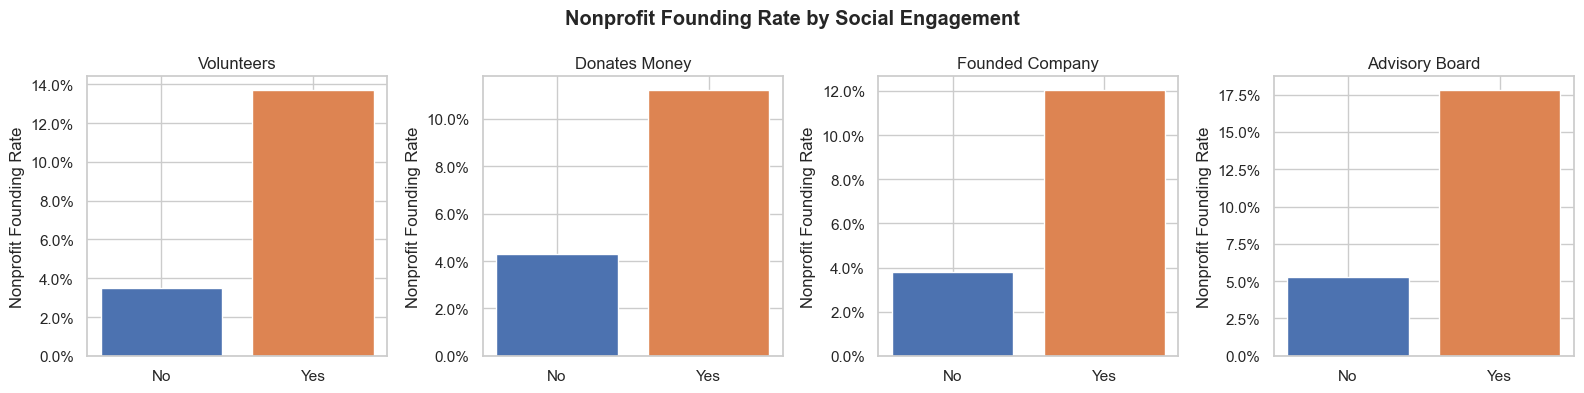

In [19]:
social_binary_cols = [c for c in ['volunteers', 'donates_money', 'founded_company', 'advisory_board'] if c in df_model.columns]

if social_binary_cols:
    rates = {col: df_model.groupby(col)[TARGET_COL].mean() for col in social_binary_cols}
    fig, axes = plt.subplots(1, len(social_binary_cols), figsize=(4 * len(social_binary_cols), 4))
    if len(social_binary_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, social_binary_cols):
        r = rates[col].reindex([0, 1])
        ax.bar(['No', 'Yes'], r.values, color=['#4C72B0', '#DD8452'])
        ax.set_title(col.replace('_', ' ').title())
        ax.set_ylabel('Nonprofit Founding Rate')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.suptitle('Nonprofit Founding Rate by Social Engagement', fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/social_engagement_rates.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.5 Numeric Feature Distributions

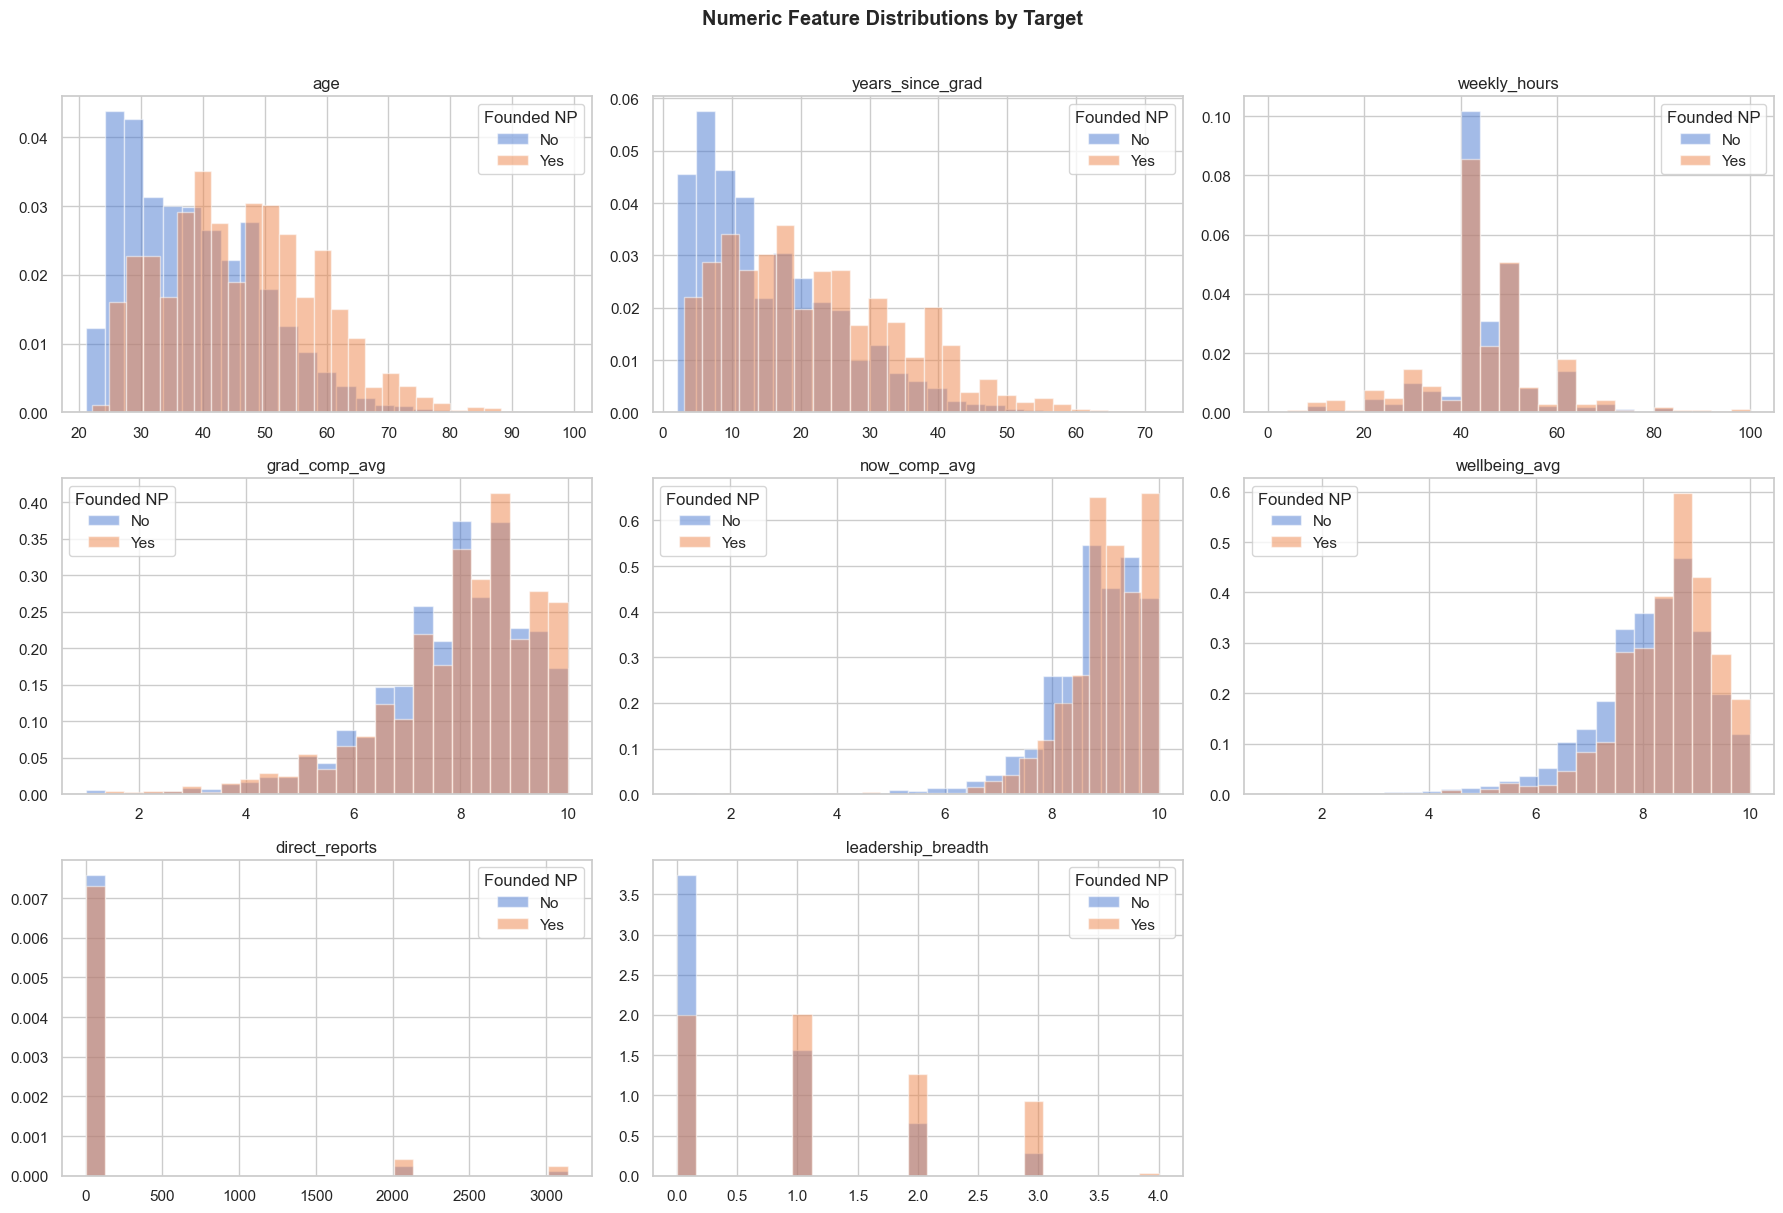

In [20]:
numeric_plot_cols = [
    c for c in [
        'age', 'years_since_grad', 'weekly_hours',
        'grad_comp_avg', 'now_comp_avg', 'wellbeing_avg',
        'volunteer_hours_month', 'direct_reports', 'leadership_breadth',
    ]
    if c in df_model.columns
]

n_cols = 3
n_rows = int(np.ceil(len(numeric_plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_plot_cols):
    for val, label in [(0, 'No'), (1, 'Yes')]:
        subset = df_model[df_model[TARGET_COL] == val][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.5, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(title='Founded NP')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Target', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.6 Competency Scores: Grad vs. Today

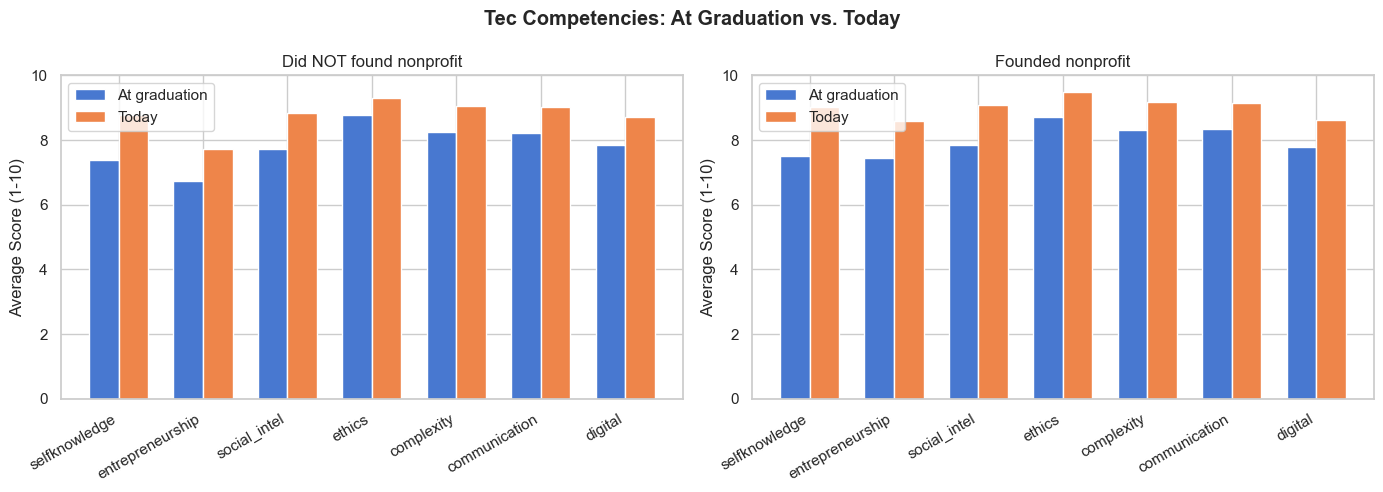

In [21]:
comp_domains_present = [d for d in comp_domains
                        if f'grad_comp_{d}' in df_model.columns and f'now_comp_{d}' in df_model.columns]

if comp_domains_present:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, target_val, title in [
        (axes[0], 0, 'Did NOT found nonprofit'),
        (axes[1], 1, 'Founded nonprofit'),
    ]:
        subset = df_model[df_model[TARGET_COL] == target_val]
        grad_means = subset[[f'grad_comp_{d}' for d in comp_domains_present]].mean().values
        now_means  = subset[[f'now_comp_{d}'  for d in comp_domains_present]].mean().values
        x = np.arange(len(comp_domains_present))
        width = 0.35
        ax.bar(x - width/2, grad_means, width, label='At graduation')
        ax.bar(x + width/2, now_means,  width, label='Today')
        ax.set_xticks(x)
        ax.set_xticklabels(comp_domains_present, rotation=30, ha='right')
        ax.set_ylim(0, 10)
        ax.set_ylabel('Average Score (1-10)')
        ax.set_title(title)
        ax.legend()
    
    plt.suptitle('Tec Competencies: At Graduation vs. Today', fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/competency_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.7 Correlation Heatmap (Numeric Features)

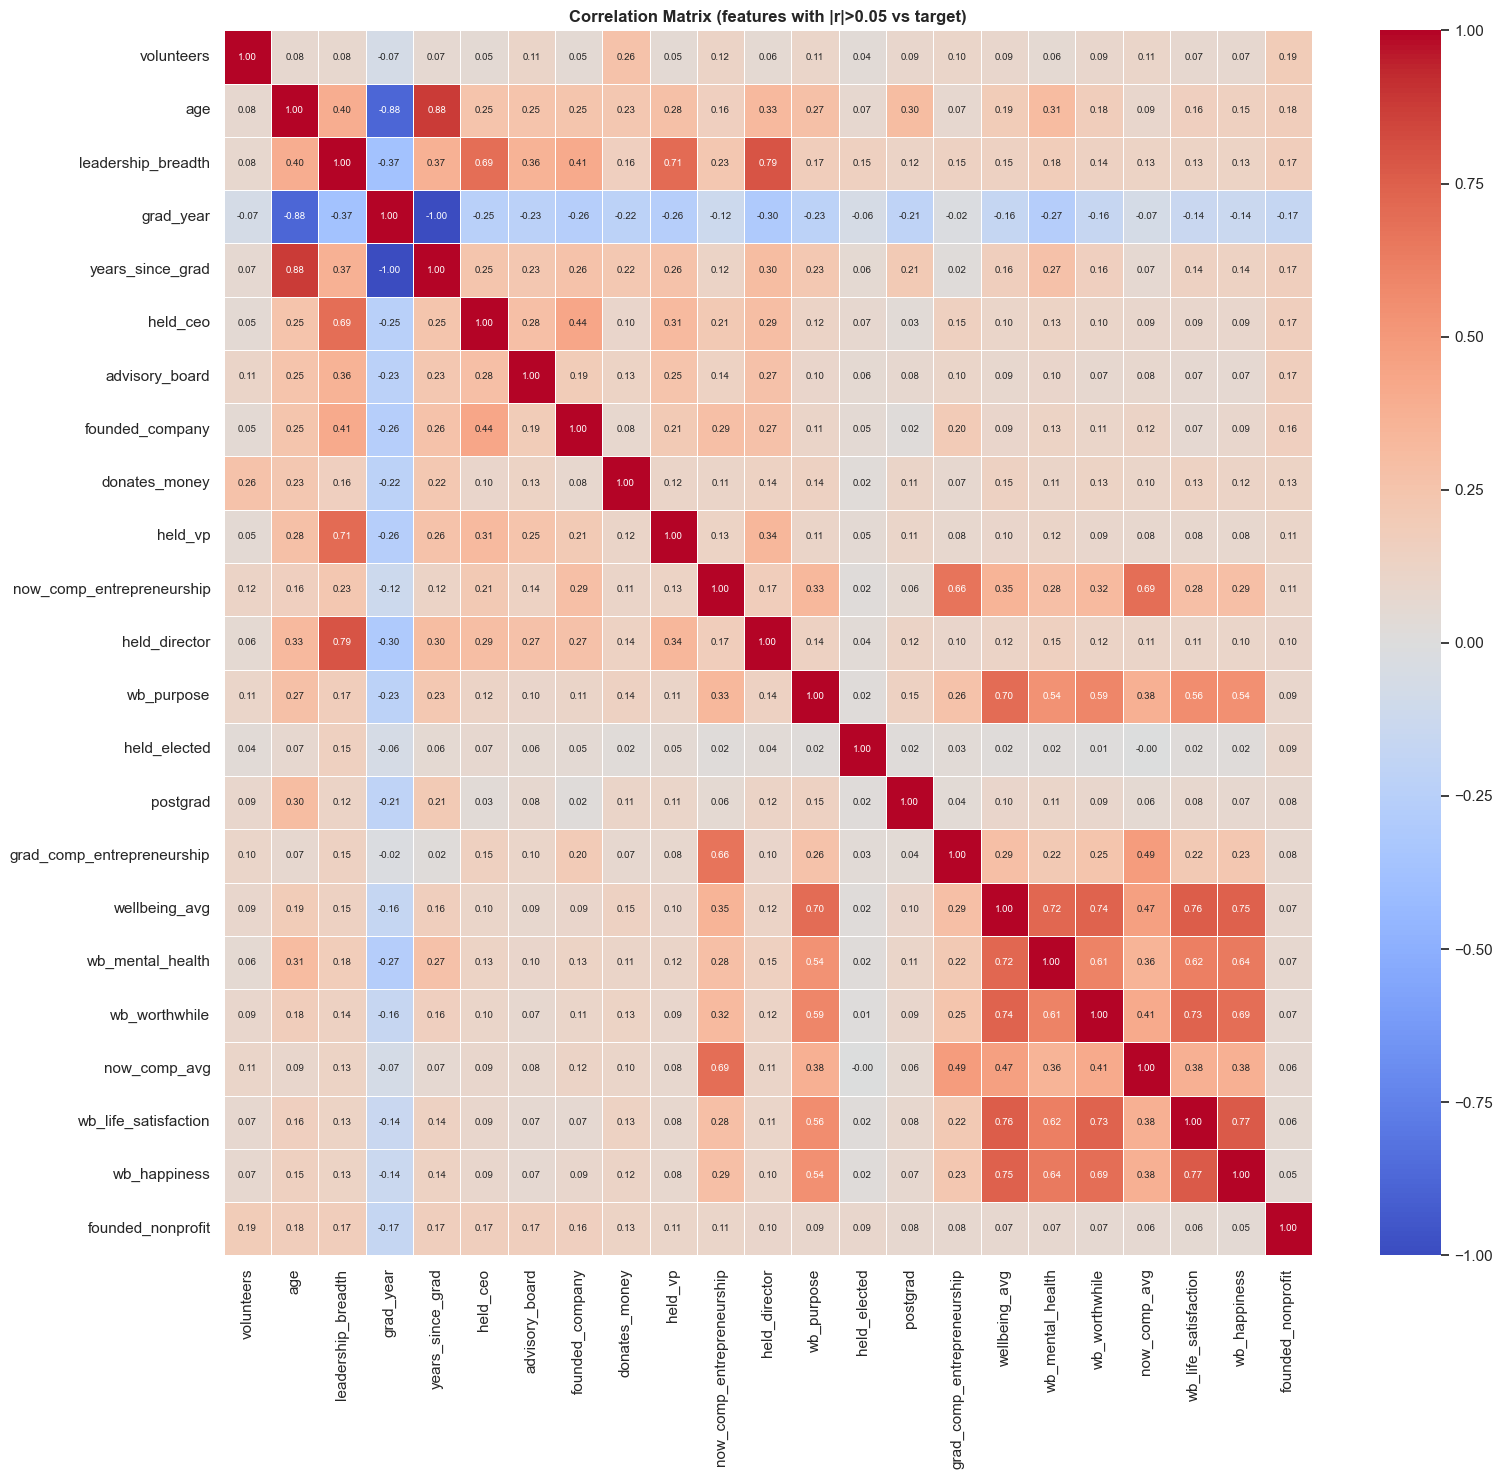

In [22]:
numeric_df = df_model.select_dtypes(include='number')
corr = numeric_df.corr()

# Show only features correlated |r| > 0.1 with target
target_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
top_corr_cols = target_corr[target_corr > 0.05].index.tolist()
sub_corr = corr.loc[top_corr_cols + [TARGET_COL], top_corr_cols + [TARGET_COL]]

fig, ax = plt.subplots(figsize=(max(10, len(sub_corr) * 0.7), max(8, len(sub_corr) * 0.65)))
sns.heatmap(
    sub_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix (features with |r|>0.05 vs target)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Top correlations with target
print('Top 20 features correlated with founded_nonprofit (|r|):')
print(target_corr.head(20).to_string())

Top 20 features correlated with founded_nonprofit (|r|):
volunteers                    0.190338
age                           0.179564
leadership_breadth            0.172138
grad_year                     0.170783
years_since_grad              0.170783
held_ceo                      0.169411
advisory_board                0.166763
founded_company               0.157324
donates_money                 0.132668
held_vp                       0.108733
now_comp_entrepreneurship     0.107498
held_director                 0.098406
wb_purpose                    0.090663
held_elected                  0.087724
postgrad                      0.077008
grad_comp_entrepreneurship    0.075091
wellbeing_avg                 0.073838
wb_mental_health              0.072400
wb_worthwhile                 0.068229
now_comp_avg                  0.064275


### 9.8 Statistical Tests (Binary Features)

In [24]:
from scipy.stats import chi2_contingency, mannwhitneyu

binary_test_cols = [c for c in BINARY_COLS if c in df_model.columns and c != TARGET_COL]
chi2_results = []
for col in binary_test_cols:
    ct = pd.crosstab(df_model[col], df_model[TARGET_COL])
    if ct.shape == (2, 2):
        chi2, p, _, _ = chi2_contingency(ct)
        chi2_results.append({'feature': col, 'chi2': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
print('Chi-square test results (binary features vs target):')
print(chi2_df.to_string(index=False))

Chi-square test results (binary features vs target):
        feature       chi2       p_value
     volunteers 917.028769 1.949886e-201
       held_ceo 725.876093 7.061902e-160
 advisory_board 703.209174 5.995845e-155
founded_company 626.312004 3.169059e-138
  donates_money 445.213554  7.939461e-99
        held_vp 298.558849  6.788160e-67
  held_director 244.721530  3.674871e-55
   held_elected 190.451159  2.534272e-43
       postgrad 149.756743  1.959432e-34
  worked_abroad  23.112503  1.527939e-06
    scholarship  13.598882  2.263203e-04


In [25]:
# Mann-Whitney U tests for numeric features
mw_results = []
numeric_test_cols = [c for c in numeric_df.columns if c != TARGET_COL]

for col in numeric_test_cols:
    g0 = df_model.loc[df_model[TARGET_COL] == 0, col].dropna()
    g1 = df_model.loc[df_model[TARGET_COL] == 1, col].dropna()
    if len(g0) > 5 and len(g1) > 5:
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        mw_results.append({'feature': col, 'U_stat': stat, 'p_value': p,
                           'mean_no': g0.mean(), 'mean_yes': g1.mean()})

mw_df = pd.DataFrame(mw_results).sort_values('p_value')
print('Mann-Whitney U test results (top 20 numeric features vs target):')
print(mw_df.head(20).to_string(index=False))

Mann-Whitney U test results (top 20 numeric features vs target):
                   feature     U_stat       p_value     mean_no    mean_yes
                volunteers 13431986.0 9.001753e-202    0.314034    0.668179
                  held_ceo 15792076.0 2.848594e-160    0.137668    0.378332
            advisory_board 16180607.0 2.307447e-155    0.116645    0.338627
                       age 13043474.5 6.412576e-151   38.309753   46.149745
        leadership_breadth 14008510.5 7.360617e-147    0.599288    1.197958
           founded_company 14550920.0 1.696035e-138    0.359895    0.660238
          years_since_grad 13562204.5 9.938045e-132   15.170220   22.366421
                 grad_year 28032254.5 9.938045e-132 2008.829780 2001.633579
             donates_money 15521578.0  4.681391e-99    0.366295    0.619966
 now_comp_entrepreneurship 15344490.5  2.978132e-78    7.710253    8.591605
                   held_vp 17683430.5  3.704226e-67    0.132751    0.282473
                wb_purp

### 9.9 Wellbeing & Competency Summary

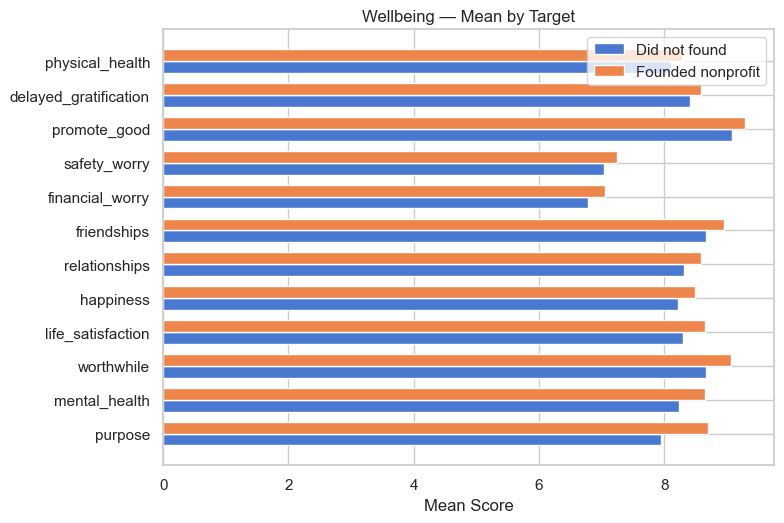

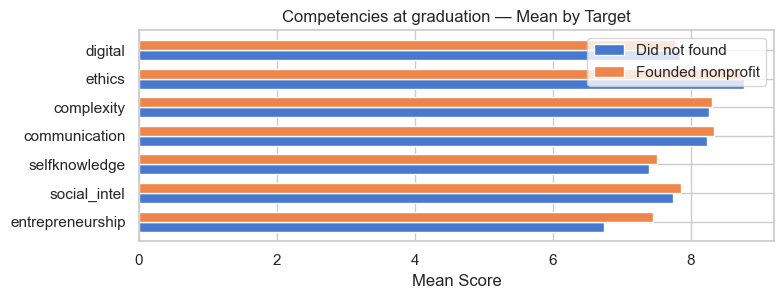

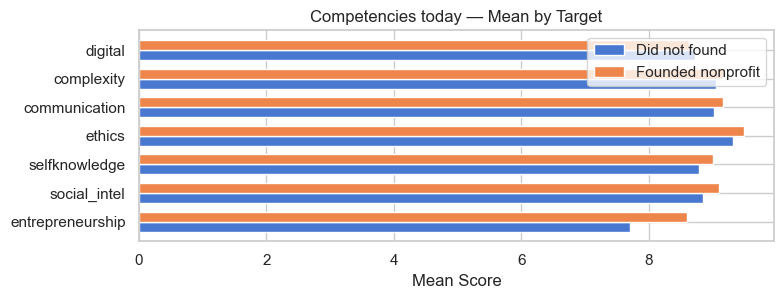

In [26]:
summary_groups = {
    'Wellbeing': [c for c in wb_cols if c in df_model.columns],
    'Competencies at graduation': [c for c in df_model.columns if c.startswith('grad_comp_') and not c.endswith('_avg')],
    'Competencies today': [c for c in df_model.columns if c.startswith('now_comp_') and not c.endswith('_avg')],
}

for group_name, cols in summary_groups.items():
    if not cols:
        continue
    summary = df_model.groupby(TARGET_COL)[cols].mean().T
    summary.columns = ['Did not found (0)', 'Founded (1)']
    summary['diff'] = summary['Founded (1)'] - summary['Did not found (0)']
    summary = summary.sort_values('diff', ascending=False)

    fig, ax = plt.subplots(figsize=(8, max(3, len(cols) * 0.45)))
    x = np.arange(len(summary))
    width = 0.35
    ax.barh(x - width/2, summary['Did not found (0)'], width, label='Did not found')
    ax.barh(x + width/2, summary['Founded (1)'],       width, label='Founded nonprofit')
    ax.set_yticks(x)
    ax.set_yticklabels([c.replace('grad_comp_', '').replace('now_comp_', '').replace('wb_', '') for c in summary.index])
    ax.set_xlabel('Mean Score')
    ax.set_title(f'{group_name} — Mean by Target')
    ax.legend()
    plt.tight_layout()
    plt.savefig('images/wellbeing_competency_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Final Preprocessed Dataset

In [27]:
# One-hot encode remaining categoricals for downstream ML
cat_cols_remaining = df_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to one-hot encode ({len(cat_cols_remaining)}): {cat_cols_remaining}')

df_encoded = pd.get_dummies(df_model, columns=cat_cols_remaining, drop_first=True, dtype=int)
print(f'Shape after one-hot encoding: {df_encoded.shape}')

Categorical columns to one-hot encode (14): ['gender', 'nationality', 'living_country', 'country_before_studies', 'program_name', 'academic_level', 'school', 'decade', 'lustrum', 'parent_edu_father', 'parent_edu_mother', 'parent_occ_father', 'parent_occ_mother', 'employment_status']
Shape after one-hot encoding: (25356, 545)


In [28]:
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Class balance: {y.mean():.2%} positive')
print('\nFeature dtypes:')
print(X.dtypes.value_counts())
X.describe().T.head(10)

Features (X): (25356, 544)
Target  (y): (25356,)
Class balance: 6.95% positive

Feature dtypes:
int64      483
float64     61
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,25356.0,38.854867,1.110562e+01,21.0,29.0,37.0,46.0,9.900000e+01
grad_year,25356.0,2008.329429,1.071775e+01,1952.0,2002.0,2011.0,2017.0,2.022000e+03
scholarship,25356.0,0.583176,4.930430e-01,0.0,0.0,1.0,1.0,1.000000e+00
scholarship_pct,25356.0,49.426250,2.162180e+01,0.0,40.0,45.0,50.0,1.000000e+02
postgrad,25356.0,0.571896,4.948137e-01,0.0,0.0,1.0,1.0,1.000000e+00
weekly_hours,25356.0,44.053005,1.072393e+01,0.0,40.0,42.0,50.0,1.000000e+02
salary_current,25356.0,176133.359914,7.355372e+06,0.0,32000.0,58990.0,100000.0,1.000000e+09
salary_first_job,25356.0,20387.073898,2.848717e+05,0.0,8000.0,13000.0,19000.0,4.000000e+07
worked_abroad,25356.0,0.317558,4.655357e-01,0.0,0.0,0.0,1.0,1.000000e+00
direct_reports,25356.0,120.730005,5.408286e+02,0.0,0.0,0.0,0.0,3.140000e+03


In [29]:
# Save preprocessed data for downstream use
df_encoded.to_csv('preprocessed_data.csv', index=False)
print('Saved preprocessed_data.csv')

Saved preprocessed_data.csv


---
## 11. Principal Component Analysis (PCA)

### 11.1 Load & Scale

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

df_pca_raw = pd.read_csv('preprocessed_data.csv')

TARGET_COL = 'founded_nonprofit'
X_pca = df_pca_raw.drop(columns=[TARGET_COL])
y_pca = df_pca_raw[TARGET_COL]

# The saved CSV may still contain NaNs from engineered features (e.g. salary_ratio).
# Impute them before scaling — PCA does not accept NaN.
remaining_nan = X_pca.isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0]
if not remaining_nan.empty:
    print('Columns with NaN before imputation:')
    print(remaining_nan.to_string())
    imputer = SimpleImputer(strategy='median')
    X_pca = pd.DataFrame(imputer.fit_transform(X_pca), columns=X_pca.columns)

# StandardScaler is required — PCA is sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

print(f'\nX shape: {X_scaled.shape}')
print(f'NaNs after scaling: {np.isnan(X_scaled).sum()}')
print(f'Class balance: {y_pca.mean():.2%} positive')

Columns with NaN before imputation:
salary_ratio    74

X shape: (25356, 544)
NaNs after scaling: 0
Class balance: 6.95% positive


### 11.2 Scree Plot & Cumulative Explained Variance

  70% variance explained by  282 components
  80% variance explained by  337 components
  90% variance explained by  397 components
  95% variance explained by  433 components


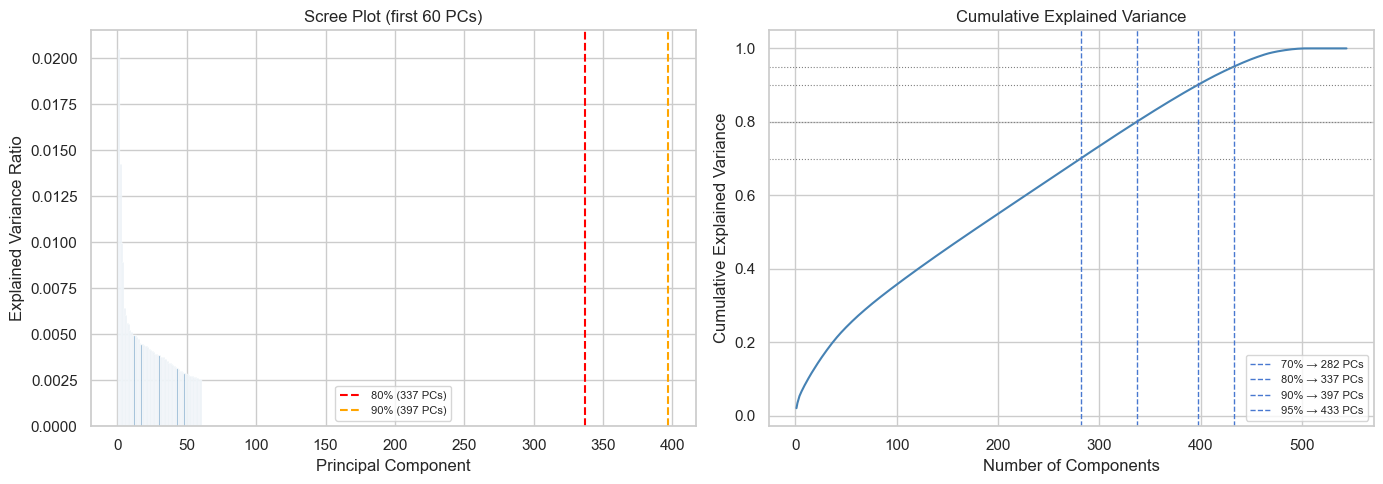

In [31]:
# Full PCA to inspect the variance spectrum
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr       = pca_full.explained_variance_ratio_
cum_evr   = np.cumsum(evr)
n_components_total = len(evr)

# Thresholds of interest
thresholds = [0.70, 0.80, 0.90, 0.95]
n_for_thresh = {t: int(np.searchsorted(cum_evr, t)) + 1 for t in thresholds}
for t, n in n_for_thresh.items():
    print(f'  {t:.0%} variance explained by {n:>4d} components')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree — first 60 components
n_show = 60
axes[0].bar(range(1, n_show + 1), evr[:n_show], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Scree Plot (first {n_show} PCs)')
axes[0].axvline(n_for_thresh[0.80], color='red',    linestyle='--', label=f'80% ({n_for_thresh[0.80]} PCs)')
axes[0].axvline(n_for_thresh[0.90], color='orange', linestyle='--', label=f'90% ({n_for_thresh[0.90]} PCs)')
axes[0].legend(fontsize=8)

# Cumulative variance — full range
axes[1].plot(range(1, n_components_total + 1), cum_evr, color='steelblue', linewidth=1.5)
for t, n in n_for_thresh.items():
    axes[1].axhline(t, linestyle=':', color='grey', linewidth=0.8)
    axes[1].axvline(n,  linestyle='--', linewidth=1,
                    label=f'{t:.0%} → {n} PCs')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('images/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Fit Reduced PCA & Project Data

In [32]:
# Choose n_components to retain 90% of variance (adjust freely)
N_COMPONENTS = n_for_thresh[0.90]
print(f'Using {N_COMPONENTS} components ({0.90:.0%} variance threshold)')

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca_reduced = pca.fit_transform(X_scaled)

# Also keep a 2-component projection for visualisation
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_scaled)

print(f'Reduced shape : {X_pca_reduced.shape}')
print(f'PC1 explains  : {pca2.explained_variance_ratio_[0]:.2%}')
print(f'PC2 explains  : {pca2.explained_variance_ratio_[1]:.2%}')
print(f'PC3 explains  : {pca3.explained_variance_ratio_[2]:.2%}')

Using 397 components (90% variance threshold)
Reduced shape : (25356, 397)
PC1 explains  : 2.05%
PC2 explains  : 1.43%
PC3 explains  : 1.00%


### 11.4 2D Scatter — PC1 vs PC2

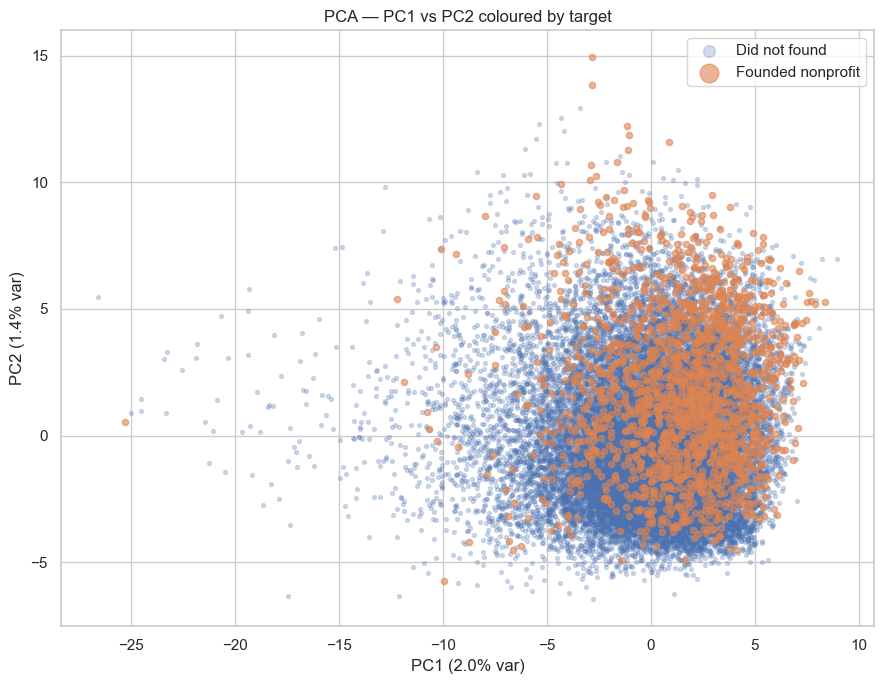

In [33]:
colors = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: 'Did not found', 1: 'Founded nonprofit'}

fig, ax = plt.subplots(figsize=(9, 7))
for cls in [0, 1]:
    mask = y_pca == cls
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], label=labels[cls],
        alpha=0.25 if cls == 0 else 0.6,
        s=8 if cls == 0 else 20,
        rasterized=True
    )
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA — PC1 vs PC2 coloured by target')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 11.5 3D Scatter — PC1 / PC2 / PC3

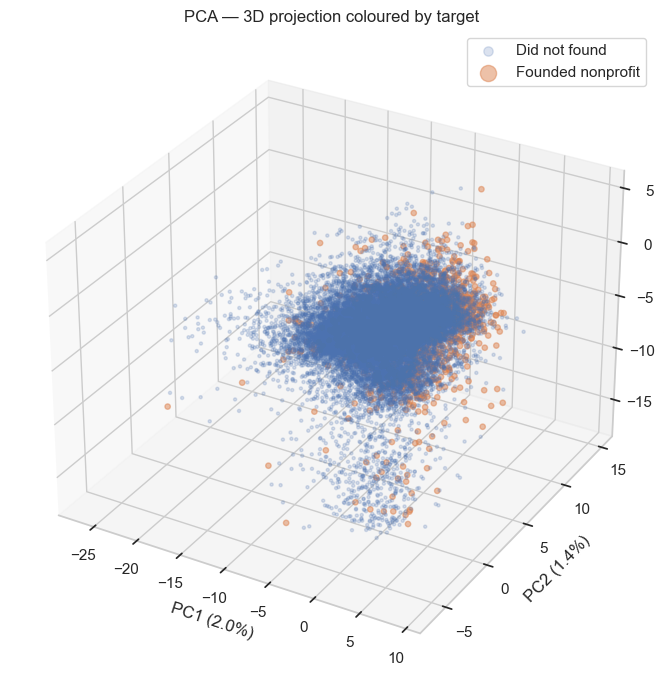

In [34]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 7))
ax3 = fig.add_subplot(111, projection='3d')

for cls in [0, 1]:
    mask = y_pca == cls
    ax3.scatter(
        X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
        c=colors[cls], label=labels[cls],
        alpha=0.2 if cls == 0 else 0.5,
        s=5 if cls == 0 else 15,
        rasterized=True
    )

evr3 = pca3.explained_variance_ratio_
ax3.set_xlabel(f'PC1 ({evr3[0]:.1%})')
ax3.set_ylabel(f'PC2 ({evr3[1]:.1%})')
ax3.set_zlabel(f'PC3 ({evr3[2]:.1%})')
ax3.set_title('PCA — 3D projection coloured by target')
ax3.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 11.6 Top Feature Loadings per PC

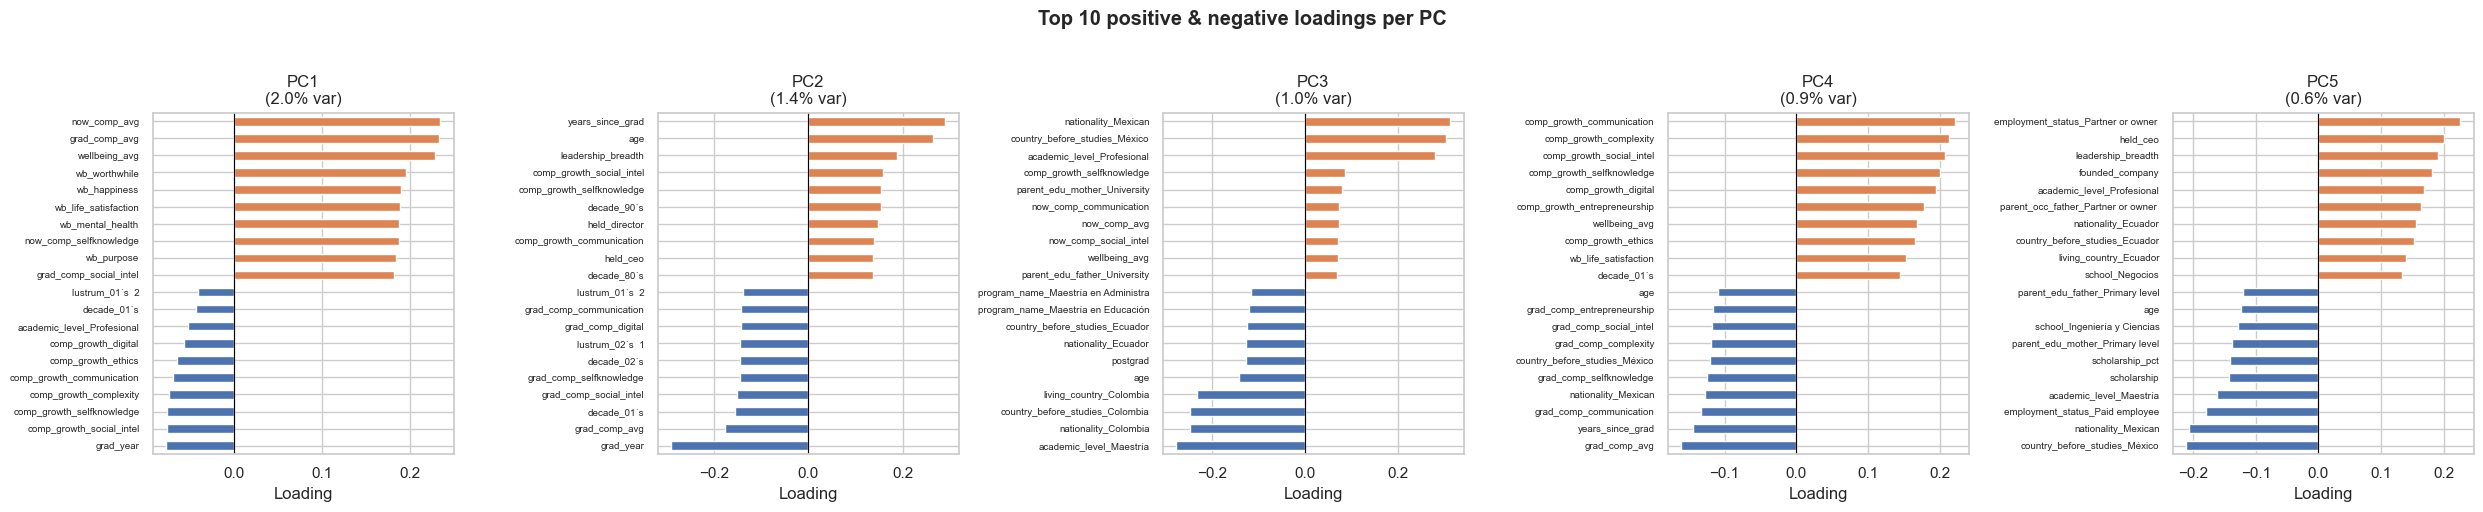

In [35]:
feature_names = X_pca.columns.tolist()
N_TOP = 10  # top loadings to show per PC
N_PCS_TO_SHOW = 5

fig, axes = plt.subplots(1, N_PCS_TO_SHOW, figsize=(5 * N_PCS_TO_SHOW, 5), sharey=False)

for i, ax in enumerate(axes):
    pc_loadings = pd.Series(pca_full.components_[i], index=feature_names)
    top = pd.concat([
        pc_loadings.nlargest(N_TOP),
        pc_loadings.nsmallest(N_TOP)
    ]).sort_values()
    colors_bar = ['#DD8452' if v > 0 else '#4C72B0' for v in top.values]
    top.plot(kind='barh', ax=ax, color=colors_bar)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{i+1}\n({pca_full.explained_variance_ratio_[i]:.1%} var)')
    ax.set_xlabel('Loading')
    # Shorten long one-hot names for readability
    ax.set_yticklabels([lbl[:35] for lbl in top.index], fontsize=7)

plt.suptitle(f'Top {N_TOP} positive & negative loadings per PC', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 11.7 Biplot (PC1 vs PC2, original feature vectors)

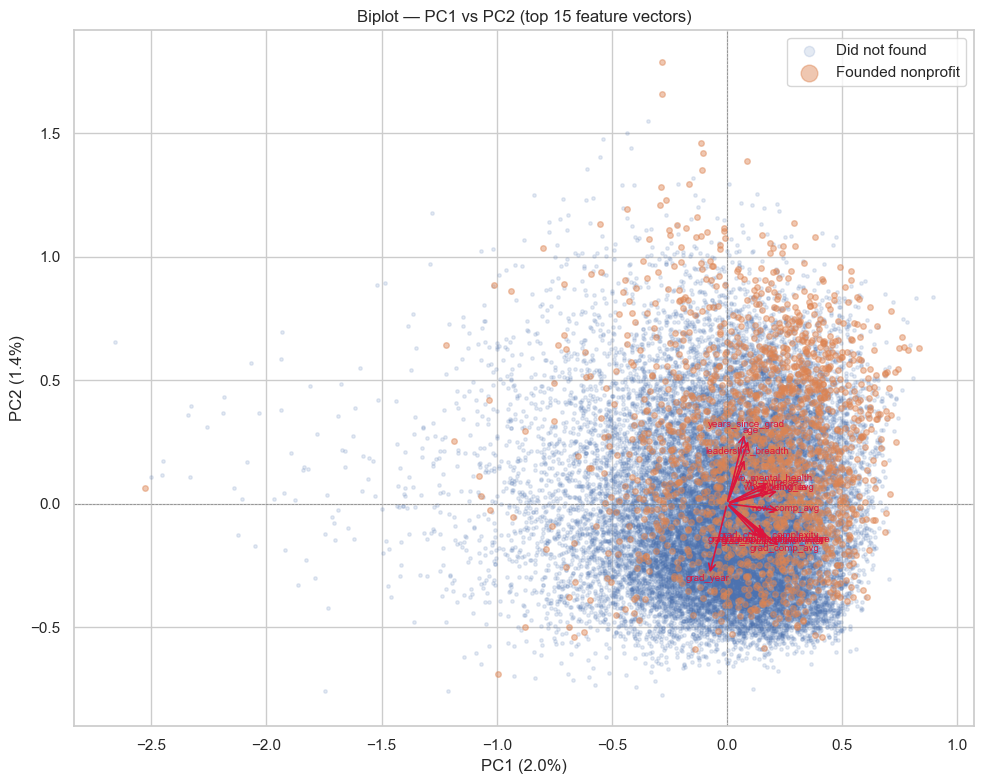

In [36]:
# Biplot: scatter of observations + arrows for the original features with
# the strongest combined loading on PC1 & PC2.
N_ARROWS = 15  # only plot top-N features by vector length to keep it readable

loadings2 = pca2.components_.T  # shape (n_features, 2)
feature_lengths = np.sqrt(loadings2[:, 0]**2 + loadings2[:, 1]**2)
top_idx = np.argsort(feature_lengths)[-N_ARROWS:]

# Scale scores to roughly fit the loadings arrow scale
scale = 1 / (X_2d.std(axis=0) * 3)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in [0, 1]:
    mask = y_pca == cls
    ax.scatter(
        X_2d[mask, 0] * scale[0],
        X_2d[mask, 1] * scale[1],
        c=colors[cls], label=labels[cls],
        alpha=0.15 if cls == 0 else 0.45,
        s=6 if cls == 0 else 16,
        rasterized=True
    )

for idx in top_idx:
    lx, ly = loadings2[idx, 0], loadings2[idx, 1]
    ax.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2)
    )
    ax.text(lx * 1.08, ly * 1.08, feature_names[idx][:30],
            fontsize=7, color='crimson', ha='center')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Biplot — PC1 vs PC2 (top {N_ARROWS} feature vectors)')
ax.legend(markerscale=3)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

### 11.8 PC Scores Correlated with Target

Top 20 PCs by |correlation| with target:
PC2      0.174402
PC1      0.114794
PC4      0.063503
PC61     0.056010
PC5      0.051893
PC11     0.051395
PC103    0.049445
PC3      0.049424
PC25     0.044963
PC6      0.044656
PC81     0.043733
PC65     0.042553
PC35     0.041857
PC10     0.039261
PC64     0.038812
PC60     0.037812
PC26     0.037450
PC45     0.036274
PC104    0.034952
PC17     0.031419


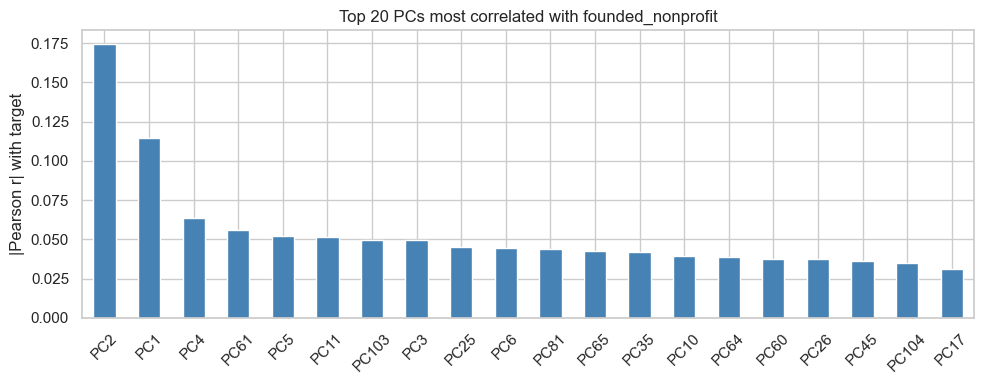

In [37]:
# Which PCs are most associated with the target?
pc_df = pd.DataFrame(
    X_pca_reduced,
    columns=[f'PC{i+1}' for i in range(X_pca_reduced.shape[1])]
)
pc_df['target'] = y_pca.values

pc_target_corr = (
    pc_df.corr()['target']
    .drop('target')
    .abs()
    .sort_values(ascending=False)
)

print('Top 20 PCs by |correlation| with target:')
print(pc_target_corr.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
pc_target_corr.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('|Pearson r| with target')
ax.set_title('Top 20 PCs most correlated with founded_nonprofit')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 11.9 Save PCA-Reduced Dataset

In [38]:
pc_df_out = pc_df.rename(columns={'target': TARGET_COL})
pc_df_out.to_csv('pca_reduced_data.csv', index=False)
print(f'Saved pca_reduced_data.csv  shape: {pc_df_out.shape}')
print('Ready for model selection.')

Saved pca_reduced_data.csv  shape: (25356, 398)
Ready for model selection.


---
## 12. Model Training & Selection

We train on **preprocessed_data.csv** (the one-hot encoded, imputed dataset from section 10).  
Models evaluated:

| Family | Models |
|---|---|
| Linear / Logistic | Logistic Regression |
| Tree-based | Decision Tree, Random Forest, Gradient Boosting |
| Density estimation | Gaussian Naive Bayes, Quadratic Discriminant Analysis (QDA) |

Because the dataset is imbalanced (~7% positive) we use **ROC-AUC** as the primary metric and also report F1, Precision, and Recall.  
All trees are kept shallow to limit compute time.

### 12.1 Load Data & Prepare Train / Test Split

In [39]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

TARGET_COL = 'founded_nonprofit'

df_ms = pd.read_csv('preprocessed_data.csv')

# Impute any residual NaNs (e.g. salary_ratio) before splitting
X_ms = df_ms.drop(columns=[TARGET_COL])
y_ms = df_ms[TARGET_COL]

if X_ms.isnull().any().any():
    imp = SimpleImputer(strategy='median')
    X_ms = pd.DataFrame(imp.fit_transform(X_ms), columns=X_ms.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_ms, y_ms, test_size=0.2, random_state=42, stratify=y_ms
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

Train: (20284, 544)  |  Test: (5072, 544)
Train positive rate: 6.95%
Test  positive rate: 6.96%


### 12.2 Define Models

In [40]:
# class_weight='balanced' compensates for the ~7% positive imbalance in all models that support it
SEED = 42

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=500, class_weight='balanced',
            solver='saga', random_state=SEED
        )),
    ]),

    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(
            max_depth=5, class_weight='balanced', random_state=SEED
        )),
    ]),

    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=6, min_samples_leaf=20,
            class_weight='balanced', n_jobs=1, random_state=SEED
        )),
    ]),

    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=SEED
        )),
    ]),

    # Density-estimation family
    'Gaussian NB': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB()),
    ]),

    'QDA': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', QuadraticDiscriminantAnalysis(reg_param=0.5)),
    ]),
}

print('Models registered:', list(models.keys()))

Models registered: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Gaussian NB', 'QDA']


### 12.3 Cross-Validated Evaluation (5-fold Stratified)

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'roc_auc':   'roc_auc',
    'f1':        'f1',
    'precision': 'precision',
    'recall':    'recall',
}

cv_results = {}
for name, pipe in models.items():
    print(f'  Evaluating: {name}...')
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {
        'ROC-AUC':   res['test_roc_auc'].mean(),
        'F1':        res['test_f1'].mean(),
        'Precision': res['test_precision'].mean(),
        'Recall':    res['test_recall'].mean(),
        'ROC-AUC std': res['test_roc_auc'].std(),
    }

cv_df = pd.DataFrame(cv_results).T.sort_values('ROC-AUC', ascending=False)
cv_df = cv_df.round(4)
print('\nCross-validated results (5-fold, train set):')
print(cv_df.to_string())

  Evaluating: Logistic Regression...
  Evaluating: Decision Tree...
  Evaluating: Random Forest...
  Evaluating: Gradient Boosting...
  Evaluating: Gaussian NB...
  Evaluating: QDA...

Cross-validated results (5-fold, train set):
                     ROC-AUC      F1  Precision  Recall  ROC-AUC std
Gradient Boosting     0.8021  0.1050     0.5828  0.0582       0.0089
Random Forest         0.7824  0.2740     0.1726  0.6638       0.0076
Logistic Regression   0.7661  0.2691     0.1689  0.6610       0.0105
Decision Tree         0.7583  0.2507     0.1549  0.6610       0.0101
QDA                   0.6593  0.1384     0.0753  0.8525       0.0082
Gaussian NB           0.4976  0.1289     0.0692  0.9418       0.0084


### 12.4 Model Comparison Plot

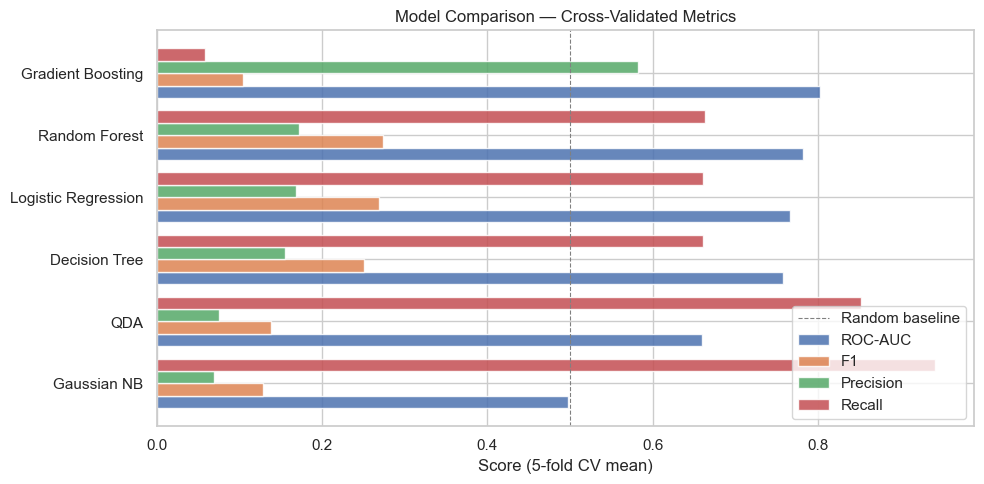

In [42]:
metrics_to_plot = ['ROC-AUC', 'F1', 'Precision', 'Recall']
plot_df = cv_df[metrics_to_plot].sort_values('ROC-AUC', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.2
colors_m = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_m)):
    bars = ax.barh(x + i * width, plot_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel('Score (5-fold CV mean)')
ax.set_title('Model Comparison — Cross-Validated Metrics')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.5 Model Selection — Best Model on Hold-Out Test Set

In [43]:
best_name = cv_df['ROC-AUC'].idxmax()
print(f'Best model by CV ROC-AUC: {best_name}  ({cv_df.loc[best_name, "ROC-AUC"]:.4f} ± {cv_df.loc[best_name, "ROC-AUC std"]:.4f})')

# Fit the best model on the full training set, evaluate on hold-out
best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)

y_pred       = best_pipe.predict(X_test)
y_proba      = best_pipe.predict_proba(X_test)[:, 1]

test_auc  = roc_auc_score(y_test, y_proba)
test_f1   = f1_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score(y_test, y_pred)

print(f'\n--- Hold-out test results ({best_name}) ---')
print(f'  ROC-AUC  : {test_auc:.4f}')
print(f'  F1       : {test_f1:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall   : {test_rec:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No nonprofit', 'Founded nonprofit']))

Best model by CV ROC-AUC: Gradient Boosting  (0.8021 ± 0.0089)

--- Hold-out test results (Gradient Boosting) ---
  ROC-AUC  : 0.8011
  F1       : 0.0972
  Precision: 0.5000
  Recall   : 0.0538

                   precision    recall  f1-score   support

     No nonprofit       0.93      1.00      0.96      4719
Founded nonprofit       0.50      0.05      0.10       353

         accuracy                           0.93      5072
        macro avg       0.72      0.52      0.53      5072
     weighted avg       0.90      0.93      0.90      5072



### 12.6 ROC Curves (All Models) & Confusion Matrix (Best Model)

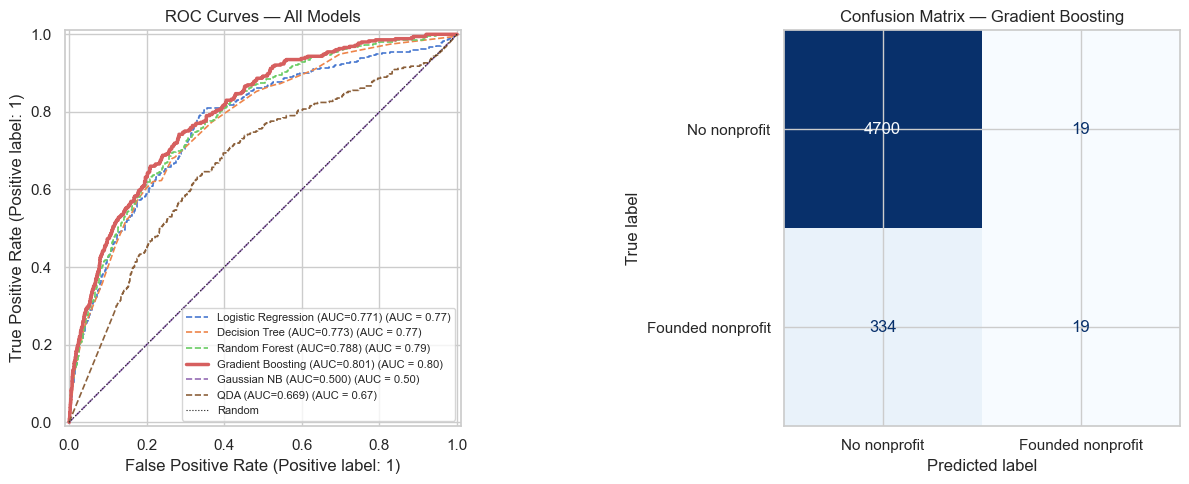

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC curves ---
ax_roc = axes[0]
for name, pipe in models.items():
    if name != best_name:
        pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    lw    = 2.5 if name == best_name else 1.2
    ls    = '-'  if name == best_name else '--'
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=f'{name} (AUC={auc:.3f})',
        ax=ax_roc, lw=lw, linestyle=ls
    )

ax_roc.plot([0, 1], [0, 1], 'k:', linewidth=0.8, label='Random')
ax_roc.set_title('ROC Curves — All Models')
ax_roc.legend(fontsize=8, loc='lower right')

# --- Confusion matrix for best model ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No nonprofit', 'Founded nonprofit'],
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title(f'Confusion Matrix — {best_name}')

plt.tight_layout()
plt.savefig('images/roc_curves_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

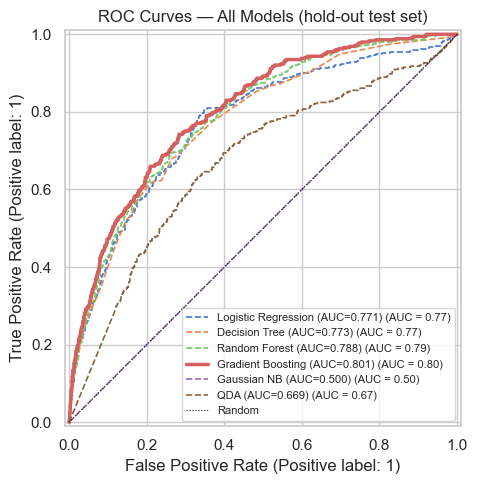

In [45]:
# ROC curves only — saved separately for the paper
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    lw    = 2.5 if name == best_name else 1.2
    ls    = '-'  if name == best_name else '--'
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=f'{name} (AUC={auc:.3f})',
        ax=ax, lw=lw, linestyle=ls
    )
ax.plot([0, 1], [0, 1], 'k:', linewidth=0.8, label='Random')
ax.set_title('ROC Curves \u2014 All Models (hold-out test set)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('images/only_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()


### 12.7 Feature Importances (Best Model)

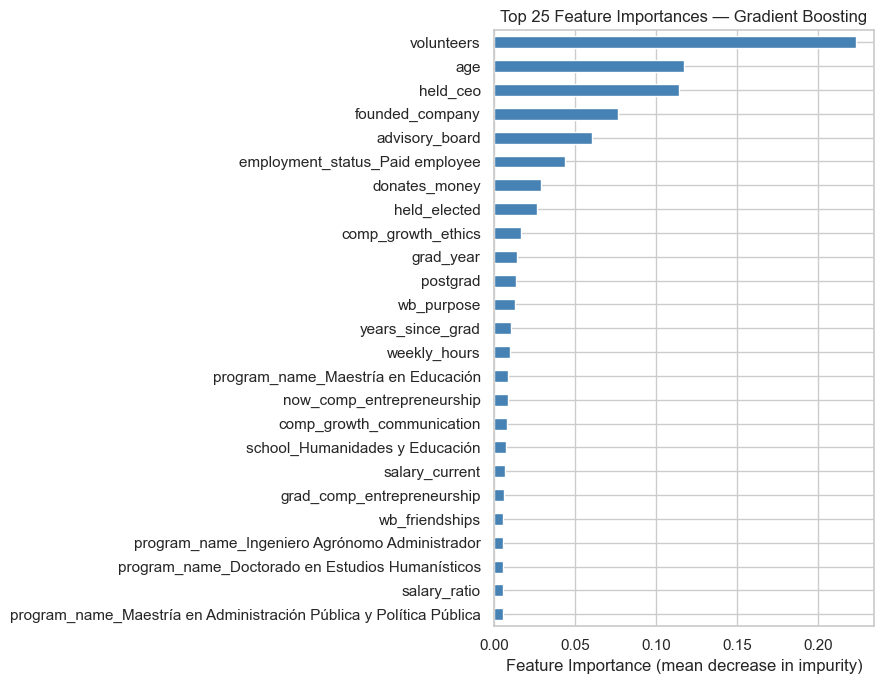

In [46]:
clf_step = best_pipe.named_steps['clf']

if hasattr(clf_step, 'feature_importances_'):
    importances = pd.Series(clf_step.feature_importances_, index=X_ms.columns)
    top_imp = importances.nlargest(25).sort_values()

    fig, ax = plt.subplots(figsize=(9, 7))
    top_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Feature Importance (mean decrease in impurity)')
    ax.set_title(f'Top 25 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.savefig('images/feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(clf_step, 'coef_'):
    coef = pd.Series(np.abs(clf_step.coef_[0]), index=X_ms.columns)
    top_coef = coef.nlargest(25).sort_values()

    fig, ax = plt.subplots(figsize=(9, 7))
    top_coef.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('|Coefficient|')
    ax.set_title(f'Top 25 Features by |Coefficient| — {best_name}')
    plt.tight_layout()
    plt.savefig('images/feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print(f'{best_name} does not expose feature importances directly.')

### 12.8 Summary

In [47]:
print('=' * 60)
print('MODEL SELECTION SUMMARY')
print('=' * 60)
print(f'\nSelected model : {best_name}')
print(f'CV ROC-AUC     : {cv_df.loc[best_name, "ROC-AUC"]:.4f} ± {cv_df.loc[best_name, "ROC-AUC std"]:.4f}')
print(f'\nHold-out test set performance:')
print(f'  ROC-AUC  : {test_auc:.4f}')
print(f'  F1       : {test_f1:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall   : {test_rec:.4f}')
print()
print('All models ranked by CV ROC-AUC:')
print(cv_df[['ROC-AUC', 'ROC-AUC std', 'F1', 'Precision', 'Recall']].to_string())

MODEL SELECTION SUMMARY

Selected model : Gradient Boosting
CV ROC-AUC     : 0.8021 ± 0.0089

Hold-out test set performance:
  ROC-AUC  : 0.8011
  F1       : 0.0972
  Precision: 0.5000
  Recall   : 0.0538

All models ranked by CV ROC-AUC:
                     ROC-AUC  ROC-AUC std      F1  Precision  Recall
Gradient Boosting     0.8021       0.0089  0.1050     0.5828  0.0582
Random Forest         0.7824       0.0076  0.2740     0.1726  0.6638
Logistic Regression   0.7661       0.0105  0.2691     0.1689  0.6610
Decision Tree         0.7583       0.0101  0.2507     0.1549  0.6610
QDA                   0.6593       0.0082  0.1384     0.0753  0.8525
Gaussian NB           0.4976       0.0084  0.1289     0.0692  0.9418


---
## 13. SHAP Analysis — Gradient Boosting

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions using `TreeExplainer`.

1. **Global importance** — mean |SHAP| bar chart
2. **Beeswarm summary** — direction + magnitude per feature
3. **Dependence plots** — top demographic & academic features
4. **Waterfall** — individual high-risk respondent explanation
5. **High-probability alumni profile** — who are they?
6. **Key findings** — actionable interpretation

### 13.1 Fit Gradient Boosting (selected model)

In [48]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

warnings.filterwarnings('ignore')

TARGET_COL = 'founded_nonprofit'
SEED = 42

df_ms = pd.read_csv('preprocessed_data.csv')
X_all = df_ms.drop(columns=[TARGET_COL])
y_all = df_ms[TARGET_COL]

if X_all.isnull().any().any():
    imp = SimpleImputer(strategy='median')
    X_all = pd.DataFrame(imp.fit_transform(X_all), columns=X_all.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb.fit(X_train, y_train)

y_proba = gb.predict_proba(X_test)[:, 1]
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(classification_report(y_test, gb.predict(X_test),
      target_names=['No nonprofit', 'Founded nonprofit']))

Test ROC-AUC: 0.8011
                   precision    recall  f1-score   support

     No nonprofit       0.93      1.00      0.96      4719
Founded nonprofit       0.50      0.05      0.10       353

         accuracy                           0.93      5072
        macro avg       0.72      0.52      0.53      5072
     weighted avg       0.90      0.93      0.90      5072



### 13.2 Compute SHAP Values

In [49]:
explainer    = shap.TreeExplainer(gb)
shap_values  = explainer.shap_values(X_test)
# Normalise shap_values to shape (n_samples, n_features).
# Some backends return a list [neg_class, pos_class]; others return a 2-D array directly.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# expected_value may be a scalar or a 1-element array.
expected_val = float(np.atleast_1d(explainer.expected_value)[-1])

print(f"SHAP matrix shape : {shap_values.shape}")
print(f"Base value (log-odds): {expected_val:.4f}")

SHAP matrix shape : (5072, 544)
Base value (log-odds): -2.9924


### 13.3 Global Feature Importance — Mean |SHAP|

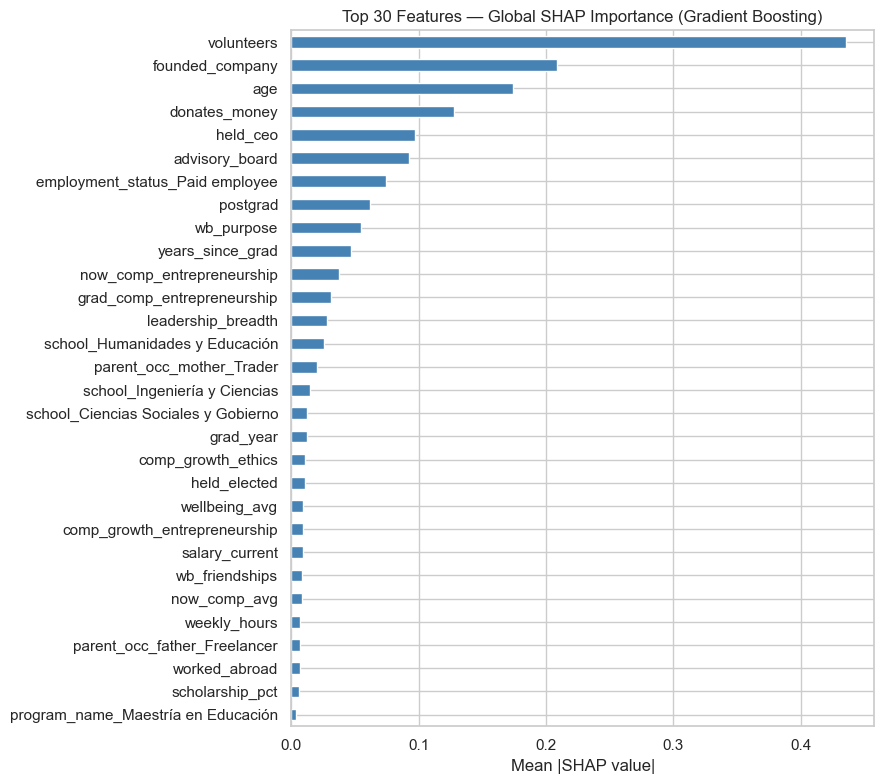

Top 20 by mean |SHAP|:
volunteers                             0.435791
founded_company                        0.208973
age                                    0.174464
donates_money                          0.127500
held_ceo                               0.096924
advisory_board                         0.092462
employment_status_Paid employee        0.074293
postgrad                               0.061435
wb_purpose                             0.054542
years_since_grad                       0.047003
now_comp_entrepreneurship              0.037786
grad_comp_entrepreneurship             0.031082
leadership_breadth                     0.027922
school_Humanidades y Educación         0.025391
parent_occ_mother_Trader               0.020266
school_Ingeniería y Ciencias           0.014431
school_Ciencias Sociales y Gobierno    0.012578
grad_year                              0.012555
comp_growth_ethics                     0.010829
held_elected                           0.010827


In [50]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

TOP_N = 30
fig, ax = plt.subplots(figsize=(9, 8))
mean_abs_shap.head(TOP_N).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {TOP_N} Features — Global SHAP Importance (Gradient Boosting)')
plt.tight_layout()
plt.savefig('images/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 by mean |SHAP|:')
print(mean_abs_shap.head(20).to_string())

### 13.4 Beeswarm Summary Plot

Red = feature value is **high**, blue = **low**.  
Position on x-axis = SHAP contribution (positive pushes toward founding a nonprofit).

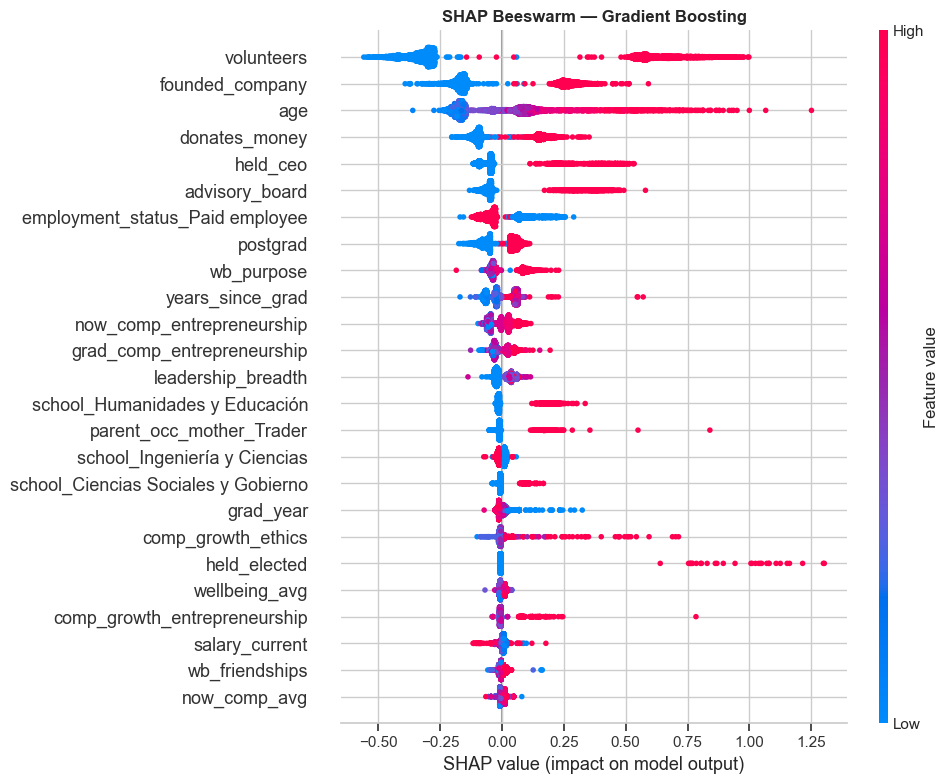

In [51]:
shap.summary_plot(
    shap_values, X_test,
    max_display=25,
    show=False,
    plot_size=(10, 8)
)
plt.title('SHAP Beeswarm — Gradient Boosting', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.savefig('images/shap_red_blue.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.5 Dependence Plots — Top Demographic & Academic Features

Each plot shows how a feature's value maps to its SHAP contribution.  
The colour encodes the most interacting feature (chosen automatically by SHAP).

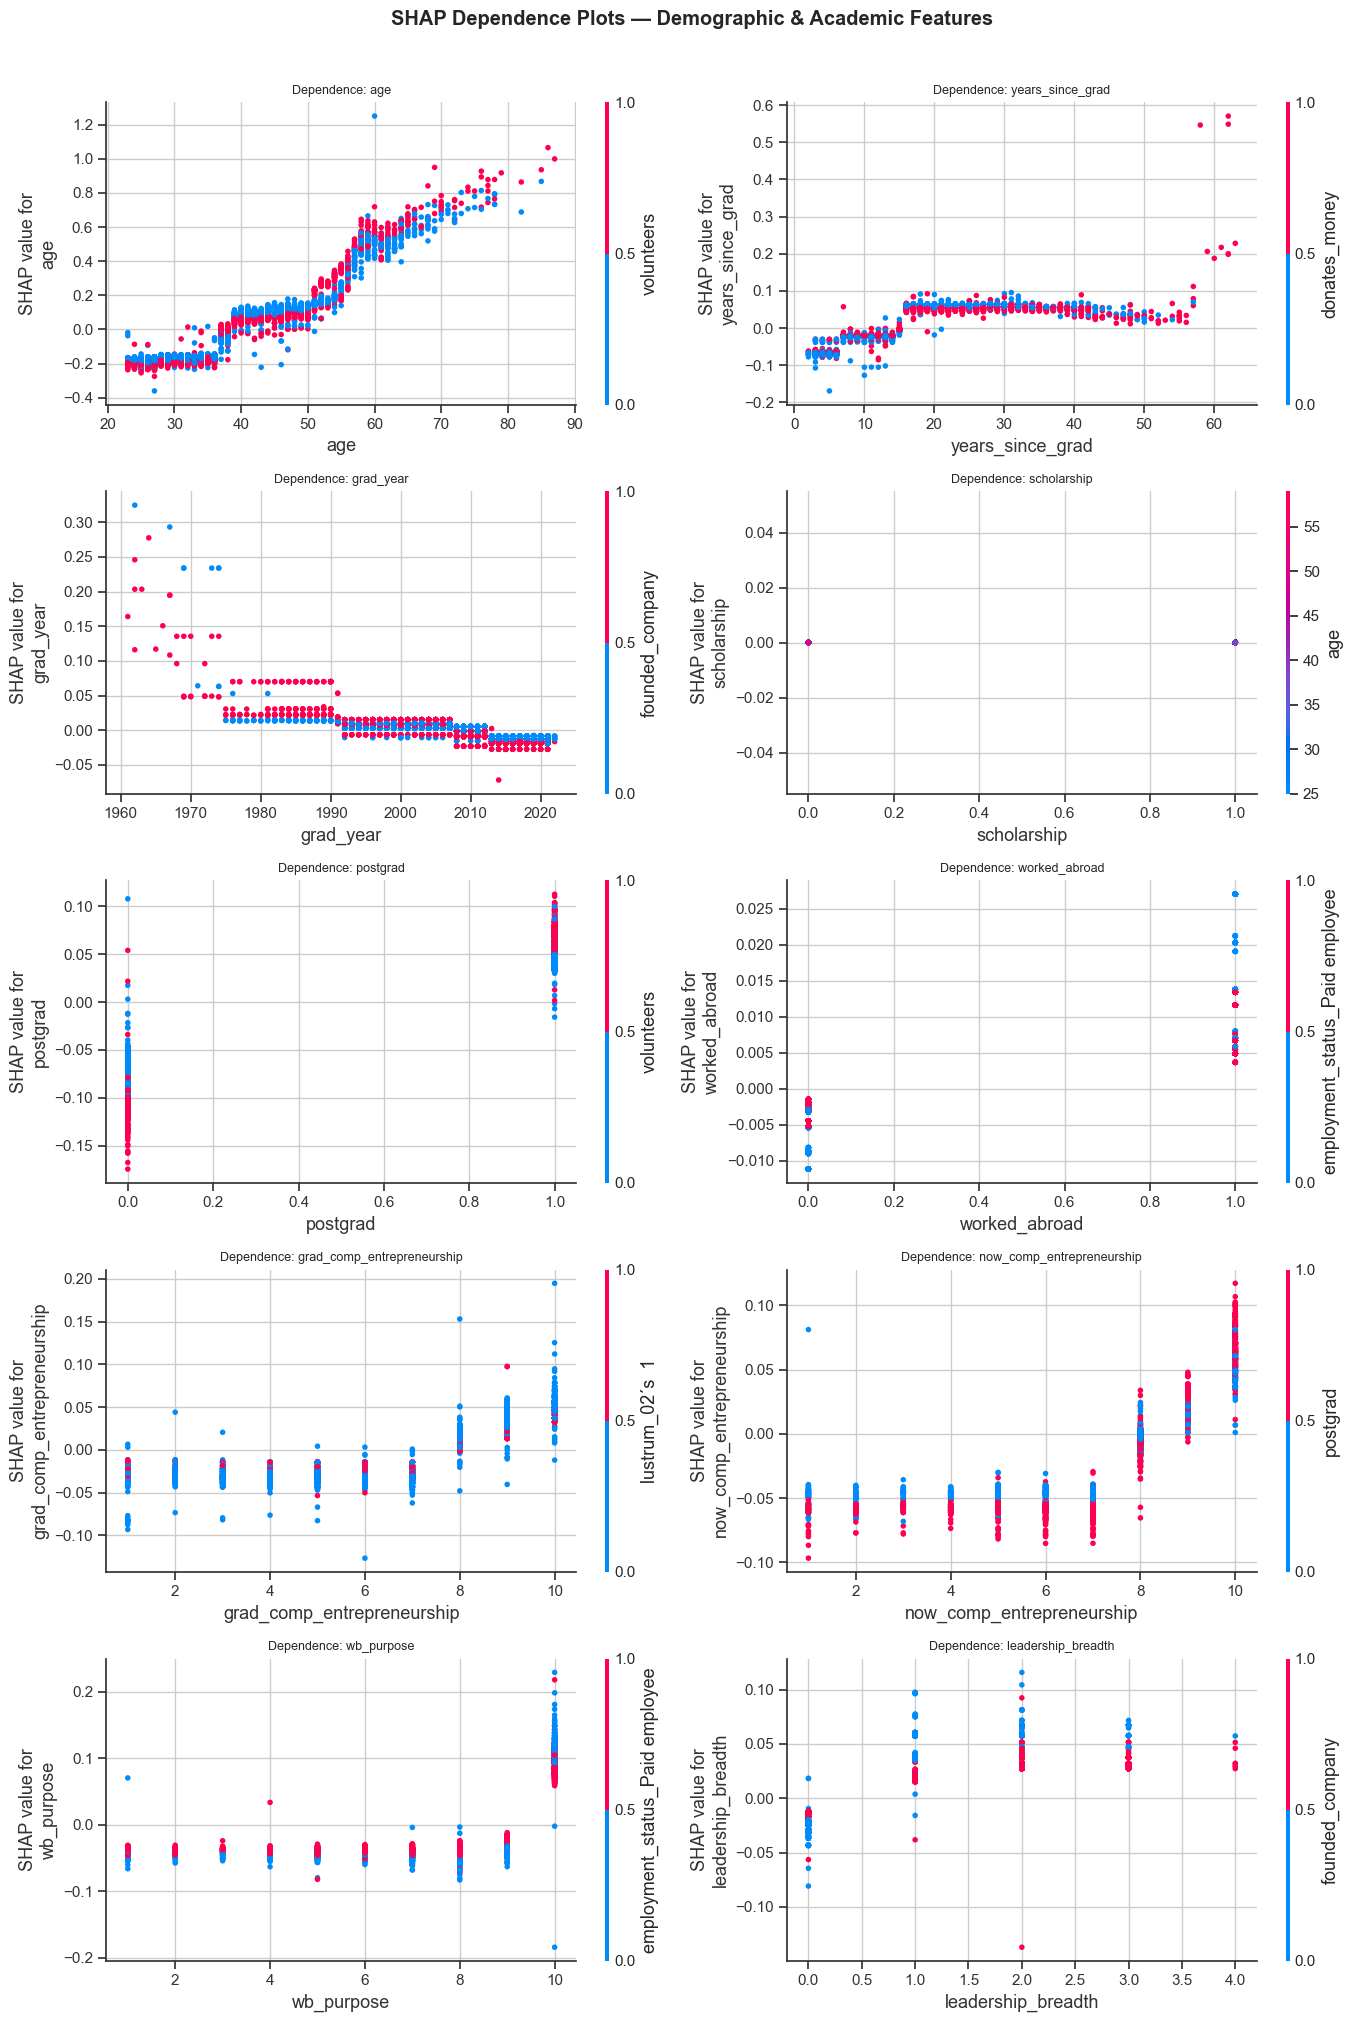

In [52]:
DEMOGRAPHIC_ACADEMIC = [
    'age', 'years_since_grad', 'grad_year',
    'scholarship', 'postgrad', 'worked_abroad',
    'grad_comp_entrepreneurship', 'now_comp_entrepreneurship',
    'wb_purpose', 'leadership_breadth',
]
top_da = [f for f in DEMOGRAPHIC_ACADEMIC if f in X_test.columns]

n_cols = 2
n_rows = int(np.ceil(len(top_da) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_da):
    shap.dependence_plot(feat, shap_values, X_test, ax=axes[i], show=False)
    axes[i].set_title(f'Dependence: {feat}', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SHAP Dependence Plots — Demographic & Academic Features',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.6 Waterfall Plot — Highest-Risk Individual

Explains the prediction for the test respondent with the **highest predicted probability**, showing exactly which features push their score up or down from the base value.

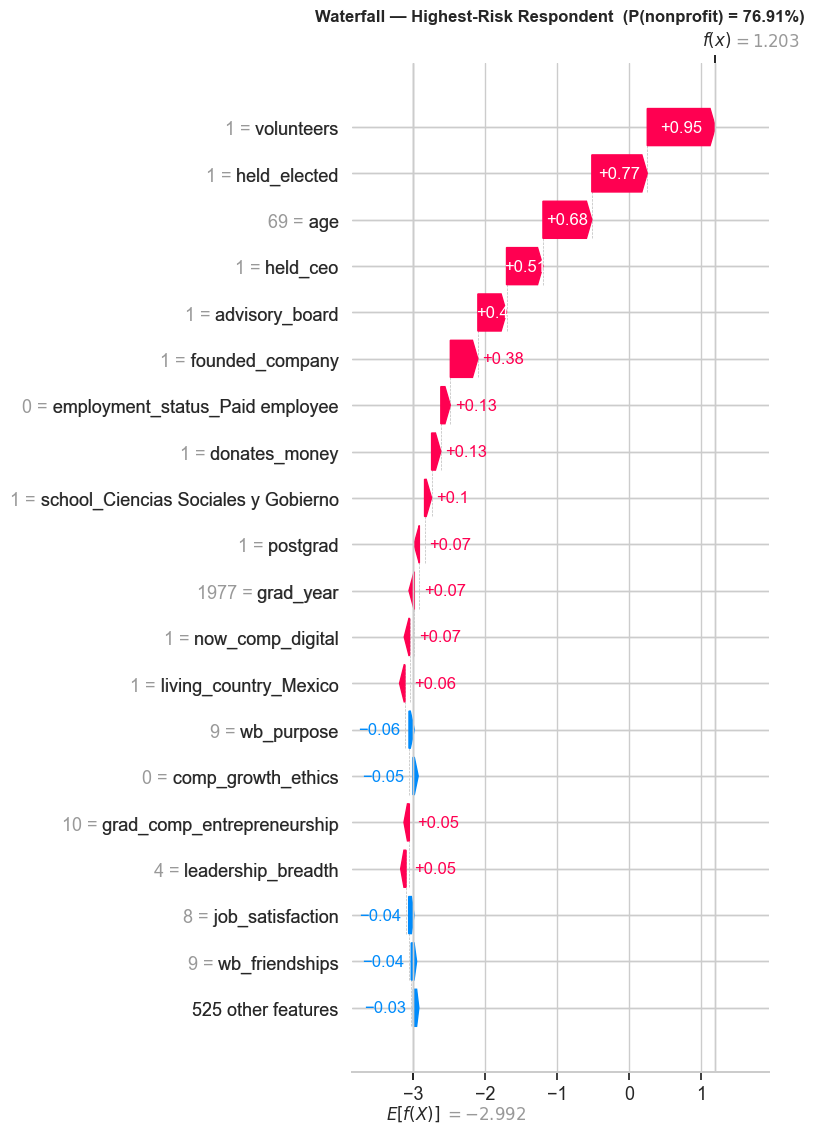

Key feature values for this respondent:
volunteers                          1.0
founded_company                     1.0
age                                69.0
donates_money                       1.0
held_ceo                            1.0
advisory_board                      1.0
employment_status_Paid employee     0.0
postgrad                            1.0
wb_purpose                          9.0
years_since_grad                   47.0
now_comp_entrepreneurship          10.0
grad_comp_entrepreneurship         10.0
leadership_breadth                  4.0
school_Humanidades y Educación      0.0
parent_occ_mother_Trader            0.0


In [53]:
high_risk_idx = int(np.argmax(y_proba))

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[high_risk_idx],
        base_values   = expected_val,
        data          = X_test.iloc[high_risk_idx].values,
        feature_names = list(X_test.columns),
    ),
    max_display=20,
    show=False
)
plt.title(
    f'Waterfall — Highest-Risk Respondent  '
    f'(P(nonprofit) = {y_proba[high_risk_idx]:.2%})',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('images/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key feature values for this respondent:')
print(X_test.iloc[high_risk_idx][mean_abs_shap.head(15).index].to_string())

### 13.7 Profile of High-Probability Alumni

We define **high-probability** as predicted score in the top decile (≥ 90th percentile) and compare their characteristics against the rest of the test set.

In [54]:
THRESHOLD_PERCENTILE = 90
threshold = np.percentile(y_proba, THRESHOLD_PERCENTILE)

df_test = X_test.copy()
df_test['pred_proba'] = y_proba
df_test['high_risk']  = (y_proba >= threshold).astype(int)
df_test['true_label'] = y_test.values

print(f'High-risk group (top {100 - THRESHOLD_PERCENTILE}%): '
      f'{df_test["high_risk"].sum()} respondents  '
      f'(threshold P >= {threshold:.3f})')
print(f'Precision in high-risk group: '
      f'{df_test.loc[df_test["high_risk"]==1, "true_label"].mean():.1%}')

High-risk group (top 10%): 508 respondents  (threshold P >= 0.156)
Precision in high-risk group: 27.8%


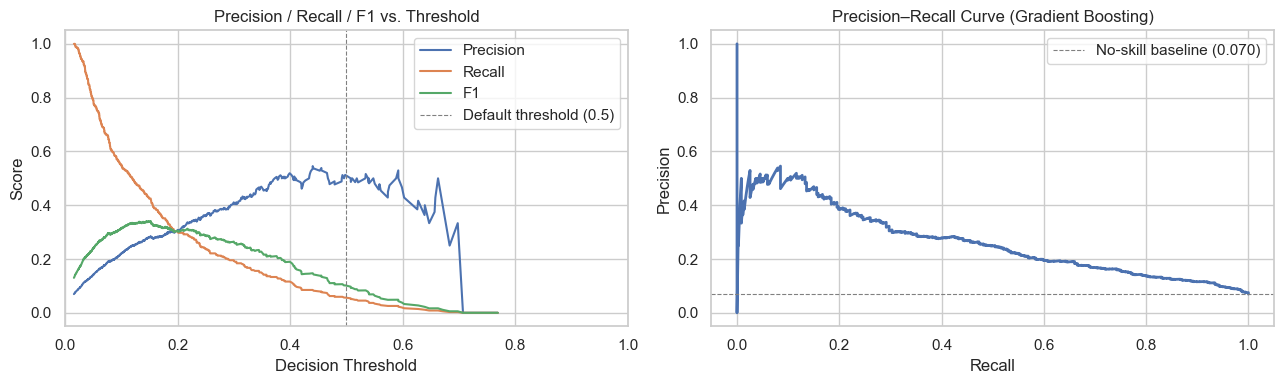

In [55]:
# Threshold sensitivity: precision, recall, F1 across decision thresholds
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds_arr, precision_arr[:-1], label='Precision', color='#4C72B0')
axes[0].plot(thresholds_arr, recall_arr[:-1],    label='Recall',    color='#DD8452')
axes[0].plot(thresholds_arr, f1_arr[:-1],        label='F1',        color='#55A868')
axes[0].axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Default threshold (0.5)')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs. Threshold')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Precision-Recall curve
axes[1].plot(recall_arr, precision_arr, color='#4C72B0', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision\u2013Recall Curve (Gradient Boosting)')
no_skill = y_test.mean()
axes[1].axhline(no_skill, color='grey', linestyle='--', linewidth=0.8, label=f'No-skill baseline ({no_skill:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
PROFILE_FEATURES = [
    'age', 'years_since_grad', 'scholarship', 'postgrad',
    'worked_abroad', 'leadership_breadth',
    'grad_comp_entrepreneurship', 'now_comp_entrepreneurship',
    'wb_purpose', 'now_comp_social_intel',
    'wb_promote_good', 'weekly_hours', 'direct_reports',
]
profile_feats = [f for f in PROFILE_FEATURES if f in df_test.columns]

profile_table = (
    df_test.groupby('high_risk')[profile_feats]
    .mean().T
    .rename(columns={0: 'Rest', 1: 'High-probability'})
)
profile_table['Diff'] = profile_table['High-probability'] - profile_table['Rest']
profile_table['Pct_change'] = (
    profile_table['Diff'] /
    profile_table['Rest'].replace(0, np.nan) * 100
).round(1)

print('Numeric profile comparison:')
print(profile_table.round(3).to_string())

Numeric profile comparison:
high_risk                      Rest  High-probability    Diff  Pct_change
age                          37.559            50.886  13.327        35.5
years_since_grad             14.580            26.986  12.406        85.1
scholarship                   0.600             0.437  -0.163       -27.2
postgrad                      0.543             0.734   0.191        35.2
worked_abroad                 0.310             0.380   0.070        22.5
leadership_breadth            0.518             1.644   1.126       217.3
grad_comp_entrepreneurship    6.679             7.701   1.021        15.3
now_comp_entrepreneurship     7.640             8.894   1.254        16.4
wb_purpose                    7.893             8.976   1.084        13.7
now_comp_social_intel         8.863             9.152   0.289         3.3
wb_promote_good               9.053             9.354   0.302         3.3
weekly_hours                 43.928            43.526  -0.402        -0.9
direct_rep

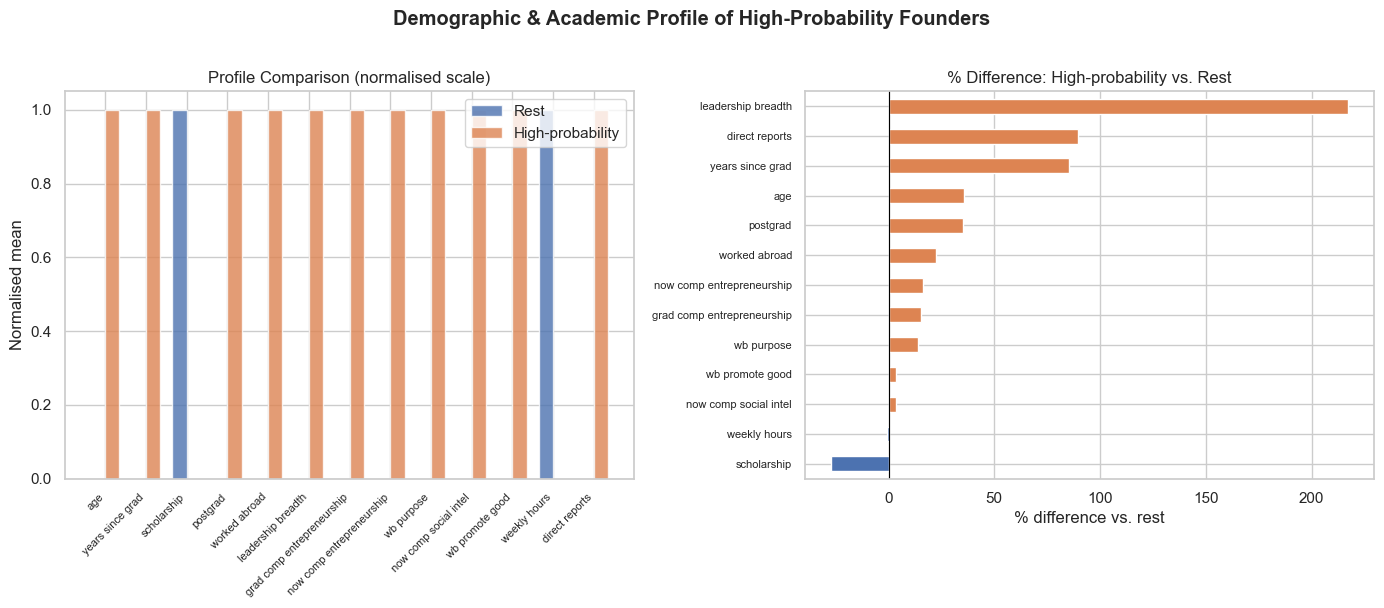

In [57]:
# ── Grouped bar: normalised values ───────────────────────────────────────
lo = profile_table[['Rest', 'High-probability']].min(axis=1)
hi = profile_table[['Rest', 'High-probability']].max(axis=1)
norm = (profile_table[['Rest', 'High-probability']]
        .sub(lo, axis=0).div((hi - lo + 1e-9), axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(profile_feats))
w = 0.35
axes[0].bar(x - w/2, norm['Rest'],             w, label='Rest',             color='#4C72B0', alpha=0.8)
axes[0].bar(x + w/2, norm['High-probability'], w, label='High-probability', color='#DD8452', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f.replace('_', ' ') for f in profile_feats],
                         rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Normalised mean')
axes[0].set_title('Profile Comparison (normalised scale)')
axes[0].legend()

diff_sorted = profile_table['Pct_change'].sort_values()
bar_colors  = ['#DD8452' if v > 0 else '#4C72B0' for v in diff_sorted]
diff_sorted.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('% difference vs. rest')
axes[1].set_title('% Difference: High-probability vs. Rest')
axes[1].set_yticklabels([f.replace('_', ' ') for f in diff_sorted.index], fontsize=8)

plt.suptitle('Demographic & Academic Profile of High-Probability Founders',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/high_prob_profile.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.8 Categorical Breakdowns by Risk Group

For each OHE categorical group, shows which categories are more prevalent among high-probability founders vs. the rest.

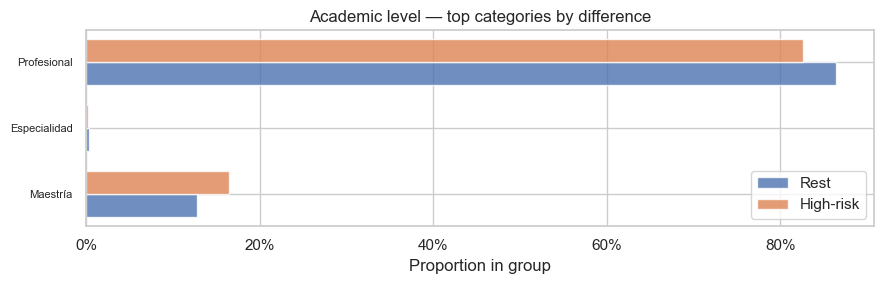

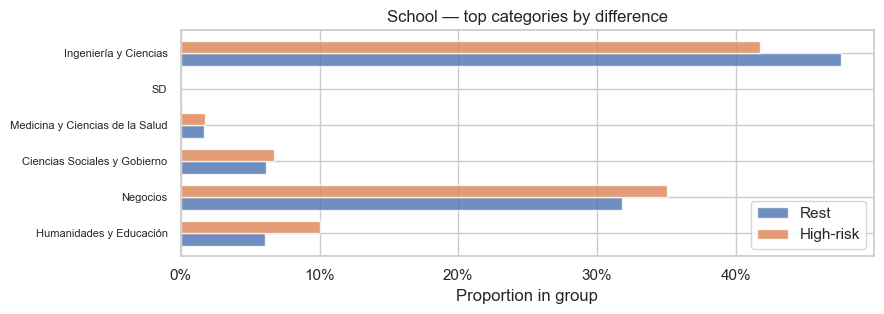

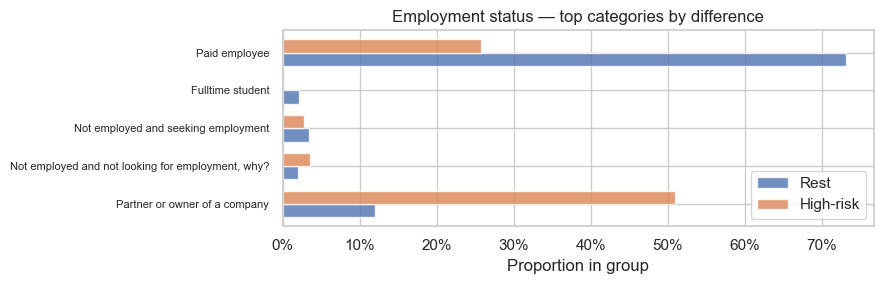

In [58]:
def top_ohe_categories(df, prefix, n=8):
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    if not cols:
        return None
    rates = (
        df.groupby('high_risk')[cols].mean().T
        .rename(columns={0: 'rest', 1: 'high_risk'})
    )
    rates['diff'] = rates['high_risk'] - rates['rest']
    rates.index = [c.replace(prefix + '_', '') for c in rates.index]
    return rates.sort_values('diff', ascending=False).head(n)

cat_groups = {
    'Academic level':     'academic_level',
    'School':             'school',
    'Employment status':  'employment_status',
}

for title, prefix in cat_groups.items():
    result = top_ohe_categories(df_test, prefix)
    if result is None:
        print(f'{title}: no columns with prefix "{prefix}_" found — skipping.')
        continue
    fig, ax = plt.subplots(figsize=(9, max(3, len(result) * 0.55)))
    x = np.arange(len(result))
    w = 0.35
    ax.barh(x - w/2, result['rest'],      w, label='Rest',       color='#4C72B0', alpha=0.8)
    ax.barh(x + w/2, result['high_risk'], w, label='High-risk',  color='#DD8452', alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels([lbl[:55] for lbl in result.index], fontsize=8)
    ax.set_xlabel('Proportion in group')
    ax.set_title(f'{title} — top categories by difference')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'images/categorical_breakdown_{prefix}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 13.9 Key Findings & Actionable Profile

In [59]:
print('=' * 65)
print('KEY FINDINGS — Who is most likely to found a nonprofit?')
print('=' * 65)

directions = {}
for feat in mean_abs_shap.head(20).index:
    if feat not in df_test.columns:
        continue
    hi = df_test.loc[df_test['high_risk'] == 1, feat].mean()
    lo = df_test.loc[df_test['high_risk'] == 0, feat].mean()
    directions[feat] = ('higher' if hi > lo else 'lower', f'{hi:.3f}', f'{lo:.3f}')

print(f'\n{"Feature":<35} {"Direction":<10} {"High-risk":>12} {"Rest":>10}')
print('-' * 70)
for feat, (direction, hi_val, lo_val) in directions.items():
    arrow = chr(8593) if direction == 'higher' else chr(8595)
    print(f'{feat:<35} {arrow + " " + direction:<10} {hi_val:>12} {lo_val:>10}')

print("""
INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Demographic signals
  • Older alumni (higher age / more years since graduation)
    have significantly higher founding probability.
    Experience, networks, and resources accumulate over time.
  • Alumni who have worked abroad show elevated probability.

Academic & competency background
  • Postgraduate studies increase the likelihood.
  • Entrepreneurship competency — both at graduation and today —
    is the strongest academic predictor after age/experience.
  • High wb_purpose (sense of purpose in life) is consistently
    elevated in founders; so is social intelligence.

Career & leadership
  • Having held CEO, VP, or NGO-head roles strongly predicts
    founding a nonprofit.
  • Leadership breadth (# of distinct senior roles) is the
    clearest career-path signal.

Behavioural signals (strongest overall)
  • Current volunteering and donating money are the two
    strongest predictors — they reflect a pre-existing
    social orientation that precedes formal founding.

Actionable implication for Tec de Monterrey
  To identify students most likely to become social
  entrepreneurs, prioritise those who:
    1. Already volunteer or donate during their studies
    2. Score high on entrepreneurship competency
    3. Report a strong sense of purpose (wb_purpose)
    4. Pursue postgraduate or international study paths
    5. Take on student leadership or advisory roles
""")

KEY FINDINGS — Who is most likely to found a nonprofit?

Feature                             Direction     High-risk       Rest
----------------------------------------------------------------------
volunteers                          ↑ higher          0.907      0.274
founded_company                     ↑ higher          0.878      0.319
age                                 ↑ higher         50.886     37.559
donates_money                       ↑ higher          0.752      0.343
held_ceo                            ↑ higher          0.591      0.106
advisory_board                      ↑ higher          0.470      0.092
employment_status_Paid employee     ↓ lower           0.258      0.731
postgrad                            ↑ higher          0.734      0.543
wb_purpose                          ↑ higher          8.976      7.893
years_since_grad                    ↑ higher         26.986     14.580
now_comp_entrepreneurship           ↑ higher          8.894      7.640
grad_comp_entreprene